### Explorative, interaktive Datenanalyse (EDA) für den Ames Housing Price Data Set

+ Verteilungsdiagramme von numerischen und kategoriale Variablen.
+ Interaktiver Scatterplot von SalePrice gegen Gr Liv Area in Bezug auf eine ausgewählte Variable.
    Wenn im Histogramm <= 30 bins gewählten, dann erlaubt die Legende im Scatterplot eine umschaltbare Anzeiger der Datenpunkte.
    Wenn eine Kategorie > 50 Ausprägungen hat, werden nur die Top 50 gezeigt, die übrigen als Andere zusammengefasst.
+ Clusteranalyse
+ Vergleich von 2 Dateien mit mindestens den Variablen SalePrice, Lot Area, Gr Liv Area

#### Versionsgeschichte

- 1.0 21.05.2025 Willi Hahn Initialversion  
- 1.1 12.09.2025 Willi Hahn Überarbeitung mit deepseek und Copilot  
- 1.2 06.10.2025 Willi Hahn bokeh durch plotly ersetzen, scheint für Chatbots zu komplex. Histogramm mit Linienplot des mittleren Saleprice ausgestattet. Ausgabe der Korrelationen mit SalePrice und anderen Variablen.
- 1.3 06.10.2025 Willi Hahn Erweiterung auf numerische Variablen mit binning  
- 1.5 10.10.2025 Willi Hahn Darstellung des binning mit Gemini auf Colab  
- 1.6 16.10.2025 Willi Hahn binning auf ganzzahlige Grenzen. Default bins = 0. bin_labels geändert. Bug in Tooltips behoben,da Bokeh Spaltennamen mit Leerzeichen nicht direkt verarbeiten kann und Unterstriche bevorzugt. Umbau auf Plotly und Panel gescheitert am Panel bug bei select widgets nur jede zweite Auswahl zu aktualisieren.
- 1.7 19.10.2025 Willi Hahn Vergleich von 2 Dateien. Clusteranalyse angefügt.
- 1.8 20.10.2025 Willi Hahn Bug bei boolean Variablen des one hot encoding entfernt.
- 1.8.1 25.10.2025 Willi Hahn Tooltips verbessert.
- 1.8.2 25.02.2026 Willi Hahn Neuer button Aktualisieren für Anzahl bins, Hypothesentest nach Kruskal-Wallis und Tests auf Normalverteilung
- 1.8.3 03.07.2026 Willi Hahn Erkennung ordinaler Variablen eingeführt. Fehlerbeseitigung. Hilfe zu Variablen aus AmesHousing Description.docx eingebaut.



Row(sizing_mode='stretch_width')
    [0] Column(width=900)
        [0] Markdown(str, styles={'font-size': '14pt', ...})
        [1] Row
            [0] TextInput(name='Dateiname', placeholder='Pfad zur ersten C..., styles={'font-size': '14pt', ...}, value='AmesHousing.csv')
            [1] Button(button_type='primary', name='Daten laden', width=100)
            [2] StaticText(styles={'font-size': '14pt', ...}, value='Daten geladen: A..., width=400)
        [2] Row
            [0] Select(name='Variable wählen', options=['', '1st Flr SF', ...], styles={'font-size': '14pt', ...}, value='1st Flr SF')
            [1] Button(button_type='primary', name='Erklärung', styles={'font-size': '14pt', ...}, width=100)
            [2] IntInput(end=100, name='Anzahl Bins', start=0, styles={'font-size': '14pt', ...}, width=200)
            [3] Button(button_type='primary', name='Refresh bins', width=100)
        [3] Card(styles={'background': '#fffbe6', ...}, title='Erklärung zur Variable', visible=False, width=880)
            [0] Markdown(str, styles={'font-size': '12pt', ...}, width=850)
            [1] Row
                [0] Button(button_type='primary', name='Schließen', width=100)
        [4] RangeSlider(end=755000, name='SalePrice Bereich', step=10000, styles={'font-size': '14pt', ...}, value=(0, 755000), value_end=755000, width=700)
        [5] RangeSlider(end=215245, name='Lot Area Bereich', step=1000, styles={'font-size': '14pt', ...}, value=(0, 215245), value_end=215245, width=700)
        [6] ParamFunction(function, _pane=Column, defer_load=False)
    [1] Column(width=900)
        [0] Markdown(str, styles={'font-size': '14pt', ...})
        [1] Row
            [0] TextInput(name='Dateiname', placeholder='Pfad zur zweiten C..., styles={'font-size': '14pt', ...}, value='Ames_Num_Small_DropFirst....)
            [1] Button(button_type='primary', name='Daten laden', width=100)
            [2] StaticText(styles={'font-size': '14pt', ...}, value='Daten geladen: A..., width=400)
        [2] Row
            [0] Select(name='Variable wählen', options=['', 'BathroomsTotal', ...], styles={'font-size': '14pt', ...}, value='BathroomsTotal')
            [1] Button(button_type='primary', name='Erklärung', styles={'font-size': '14pt', ...}, width=100)
            [2] IntInput(end=100, name='Anzahl Bins', start=0, styles={'font-size': '14pt', ...}, width=200)
            [3] Button(button_type='primary', name='Refresh bins', width=100)
        [3] Card(styles={'background': '#fffbe6', ...}, title='Erklärung zur Variable', visible=False, width=880)
            [0] Markdown(str, styles={'font-size': '12pt', ...}, width=850)
            [1] Row
                [0] Button(button_type='primary', name='Schließen', width=100)
        [4] RangeSlider(end=625000, name='SalePrice Bereich', step=10000, styles={'font-size': '14pt', ...}, value=(0, 625000), value_end=625000, width=700)
        [5] RangeSlider(end=215245, name='Lot Area Bereich', step=1000, styles={'font-size': '14pt', ...}, value=(0, 215245), value_end=215245, width=700)
        [6] ParamFunction(function, _pane=Column, defer_load=False)
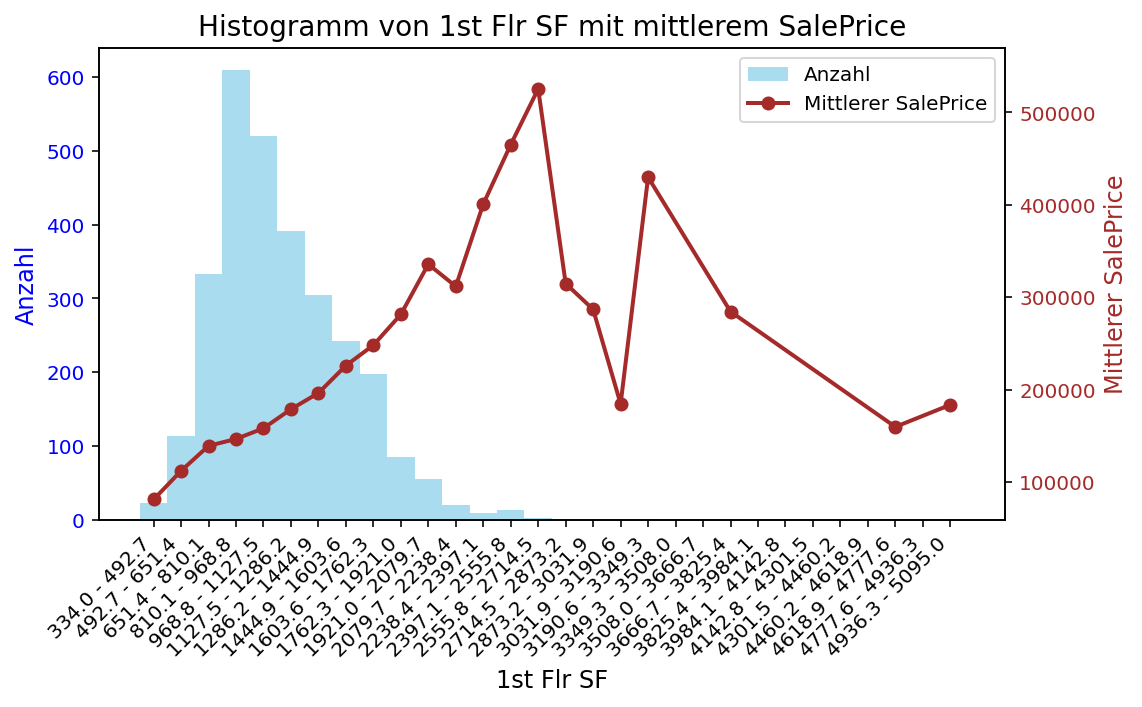
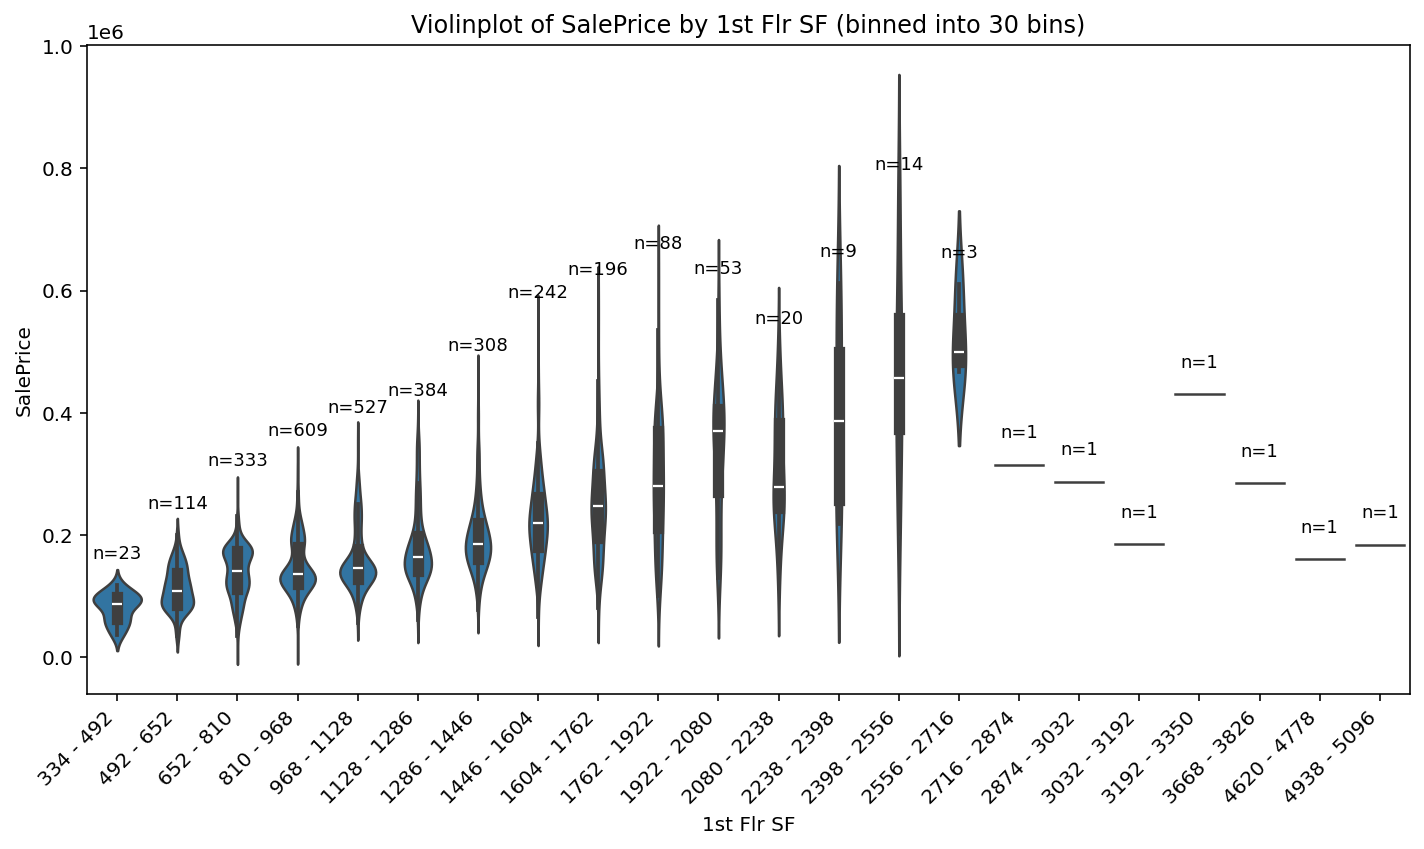
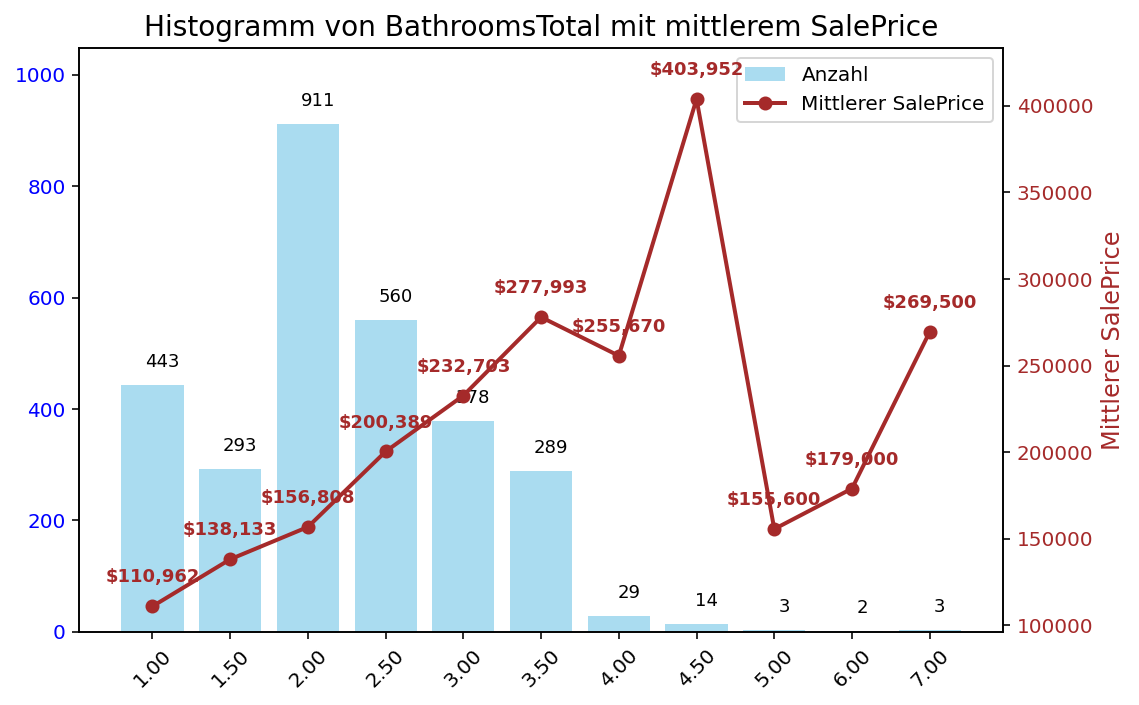
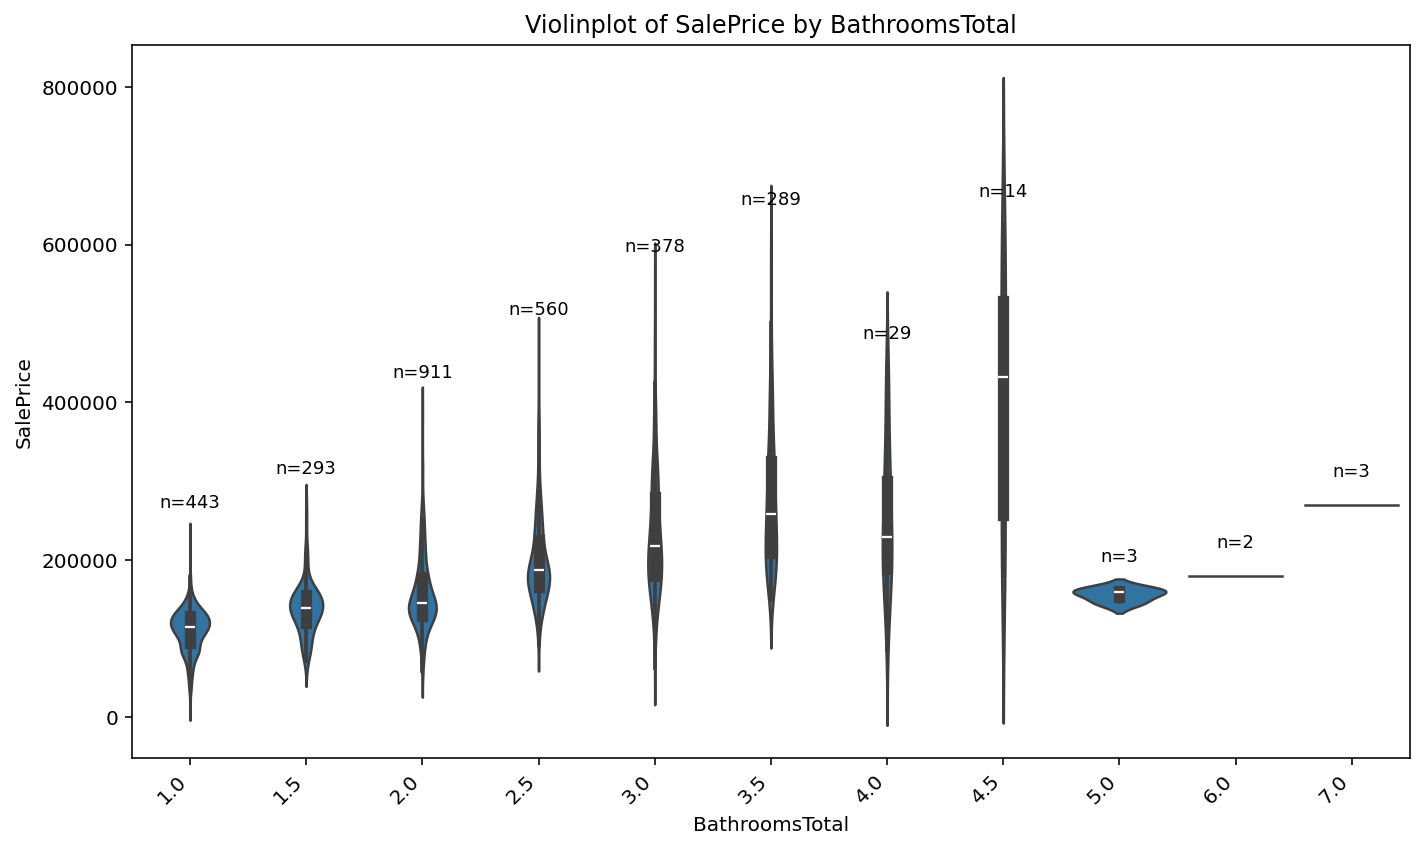

In [24]:
import pandas as pd
from pandas.api.types import is_bool_dtype, is_integer_dtype, is_float_dtype, is_numeric_dtype
from scipy.stats import kruskal, shapiro, normaltest, anderson
import numpy as np
import matplotlib.pyplot as plt
import bokeh   # graphische, interaktive Plots
from bokeh.plotting import figure, show
from bokeh.transform import factor_cmap, factor_mark
from bokeh.palettes import Category10
from bokeh.models import ColumnDataSource, HoverTool, PanTool, ZoomInTool, ZoomOutTool, SaveTool, WheelZoomTool, BoxZoomTool, ResetTool
from bokeh.models import  Legend, LegendItem, NumeralTickFormatter
import param

from bokeh.transform import linear_cmap
from bokeh.palettes import Viridis256
from bokeh.models import ColorBar, LinearColorMapper
from bokeh.transform import linear_cmap, factor_cmap
from bokeh.palettes import Viridis256, Category10, Category20


import zipfile  # für Hilfedatei im docx Format
import xml.etree.ElementTree as ET
import re
import os


try:
    # Für lokale Jupyter Notebooks
    from bokeh.io import output_notebook, show
    _= output_notebook(resources=None, verbose=True, hide_banner=True)
    # Panel extension mit allen notwendigen Komponenten
    import panel as pn
    pn.extension('tabulator')
    slider_css = """
    .noUi-connect {
        background: #005A9E !important;
    }
    
    .noUi-handle {
        background: #003F73 !important;
        border: 2px solid #002B50 !important;
        box-shadow: 0 0 4px rgba(0,0,0,0.35) !important;
    }
    
    .noUi-handle:hover {
        background: #0078D4 !important;
    }
    
    .noUi-target {
        background: #D6EAF8 !important;
        border: 1px solid #7FB3D5 !important;
    }
    
    .bk-input-group label,
    .bk-slider-title {
        color: #003F73 !important;
        font-weight: bold !important;
    }
    """
    
    pn.config.raw_css.append(slider_css)
except Exception as e:
    print(f"Initialisierungsfehler: {e}")
        
from IPython.display import display

# Seaborn für Violinplots importieren (falls nicht vorhanden, wird Boxplot als Fallback verwendet)
try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("Seaborn nicht gefunden, verwende Boxplot als Fallback für Violinplots.")

try:
    import google.colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    try:
        import jupyter_bokeh
    except ImportError:
        print("jupyter_bokeh not found, installing...")
        !pip install jupyter_bokeh
        try:
            import jupyter_bokeh
        except Exception as e:
            print(f"Failed to import jupyter_bokeh after installation: {e}")
#else:
#    print("Not in Google Colab environment, skipping jupyter_bokeh installation.")

# Globale Variablen für beide Datensätze
df1 = None
df2 = None
initial_filename = 'https://raw.githubusercontent.com/WilliHahn/FHDW/main/AmesHousing.csv' if IS_COLAB else 'AmesHousing.csv'
initial_filename2 = 'https://raw.githubusercontent.com/WilliHahn/FHDW/main/Ames_Num_Small_DropFirst.csv' if IS_COLAB else 'Ames_Num_Small_DropFirst.csv'
help_filename  = 'https://raw.githubusercontent.com/WilliHahn/FHDW/main/AmesHousing Description.docx' if IS_COLAB else 'AmesHousing Description.docx'
# DEBUG Flag
DEBUG = False

def debug_print(message):
    if DEBUG:
        print(f"DEBUG: {message}")


def read_docx_text(filename):
    """
    Liest den reinen Text aus einer .docx-Datei ohne zusätzliche Bibliothek.
    Funktioniert nicht für alte .doc-Dateien.
    """

    try:
        with zipfile.ZipFile(filename) as docx_zip:
            xml_content = docx_zip.read("word/document.xml")

        root = ET.fromstring(xml_content)

        namespace = {
            "w": "http://schemas.openxmlformats.org/wordprocessingml/2006/main"
        }

        paragraphs = []

        for paragraph in root.findall(".//w:p", namespace):
            texts = []

            for text_node in paragraph.findall(".//w:t", namespace):
                if text_node.text:
                    texts.append(text_node.text)

            if texts:
                paragraphs.append("".join(texts))

        return "\n".join(paragraphs)

    except Exception as e:
        print(f"Fehler beim Lesen der Word-Datei {filename}: {e}")
        return ""        

def build_ames_help_dict(raw_text):
    """
    Zerlegt den langen Ames-Beschreibungstext in einzelne Hilfetexte pro Variable.
    Überschriften werden erkannt, wenn sie z.B. so aussehen:
    Variable Name (Type): Beschreibung
    """

    help_dict = {}
    current_var = None
    current_lines = []

    header_pattern = re.compile(r"^([A-Za-z0-9][A-Za-z0-9 /\-&]+?)\s*\(([^)]+)\):\s*(.*)$")

    for line in raw_text.splitlines():

        match = header_pattern.match(line.strip())

        if match:
            if current_var is not None:
                help_dict[current_var] = "\n".join(current_lines).strip()

            var_name = match.group(1).strip()
            var_type = match.group(2).strip()
            description = match.group(3).strip()

            current_var = var_name
            current_lines = [
                f"### {var_name}",
                f"**Typ:** {var_type}",
                "",
                description
            ]

        else:
            if current_var is not None:
                current_lines.append(line)

    if current_var is not None:
        help_dict[current_var] = "\n".join(current_lines).strip()

    return help_dict

HELP_ALIASES = {
    'ExterQual': 'Exter Qual',
    'Exter Qual': 'ExterQual',

    'HeatingQC': 'Heating QC',
    'Heating QC': 'HeatingQC',

    'KitchenQual': 'Kitchen Qual',
    'Kitchen Qual': 'KitchenQual',

    'TotRmsAbvGrd': 'TotRms AbvGrd',
    'TotRms AbvGrd': 'TotRmsAbvGrd',

    'FireplaceQu': 'Fireplace Qu',
    'Fireplace Qu': 'FireplaceQu',

    'BsmtFinType 2': 'BsmtFin Type 2',
    'BsmtFin Type 2': 'BsmtFinType 2',

    '3-Ssn Porch': '3Ssn Porch',
    '3Ssn Porch': '3-Ssn Porch',

    'Bedroom': 'Bedroom AbvGr',
    'Bedroom AbvGr': 'Bedroom',

    'Kitchen': 'Kitchen AbvGr',
    'Kitchen AbvGr': 'Kitchen',

    'Names': 'NAmes',
    'NAmes': 'Names'
}

def get_help_text_for_variable(variable_name):
    """
    Liefert den Hilfetext zur ausgewählten Variable.
    Wenn die Hilfedatei nicht gefunden oder nicht gelesen wurde,
    wird eine entsprechende Meldung angezeigt.
    """

    if AMES_HELP_LOAD_ERROR is not None:
        return f"### Hilfe\n\n**{AMES_HELP_LOAD_ERROR}**"

    if not variable_name:
        return "### Hilfe\n\nKeine Variable ausgewählt."

    if variable_name in AMES_HELP:
        return AMES_HELP[variable_name]

    alias = HELP_ALIASES.get(variable_name)

    if alias and alias in AMES_HELP:
        return AMES_HELP[alias]

    return f"### {variable_name}\n\nKeine Erklärung für diese Variable gefunden."    

# --------------------------------------------------
# Hilfetext aus Word-Datei laden
# --------------------------------------------------

AMES_HELP_LOAD_ERROR = None

if not os.path.exists(help_filename):
    AMES_HELP_RAW = ""
    AMES_HELP = {}
    AMES_HELP_LOAD_ERROR = f"Hilfedatei {help_filename} nicht gefunden"
else:
    AMES_HELP_RAW = read_docx_text(help_filename)

    if AMES_HELP_RAW.strip() == "":
        AMES_HELP = {}
        AMES_HELP_LOAD_ERROR = f"Hilfedatei {help_filename} konnte nicht gelesen werden"
    else:
        AMES_HELP = build_ames_help_dict(AMES_HELP_RAW)

# Funktion zum Laden der Daten
def load_data(filename):
    try:
        debug_print(f"Lade Datei: {filename}")
        # Daten einlesen
        df = pd.read_csv(filename, sep=',', keep_default_na=False)  #Standard-NA-Erkennung deaktiviert 
        debug_print(f"Erfolgreich geladen: {len(df)} Zeilen, {len(df.columns)} Spalten")
        
        # Debug: Zeige Datentypen aller Spalten
        #debug_print("Datentypen der Spalten:")
        #for col in df.columns:
            #debug_print(f"  {col}: {df[col].dtype}, erste Werte: {df[col].head(3).tolist()}")
            
        return df
    except Exception as e:
        print(f"Fehler beim Laden der Datei {filename}: {e}")
        return None

# Initial Daten laden
debug_print("Starte initiales Laden der Daten für Datensatz 1")
df1 = load_data(initial_filename)

debug_print("Starte initiales Laden der Daten für Datensatz 2")
df2 = load_data(initial_filename2)

if df1 is not None:
#    y = df1['SalePrice']
#    X = df1.drop(columns=['SalePrice'])

    # einige Spalten explizit in kategortialen Datentyp umwandeln
    #debug_print("Konvertiere 'Overall Qual' und 'Overall Cond' zu string")
    #df1['Overall Qual'] = df1['Overall Qual'].astype('string')
    #df1['Overall Cond'] = df1['Overall Cond'].astype('string')

    # Liste der Spalten, die definitiv numerisch sein sollten, auch wenn NaN vorhanden sind
    numeric_columns = [
        'Lot Frontage', 'Lot Area',
        'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1',
        'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF',
        '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
        'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
        'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt',
        'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF',
        'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area',
        'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice'
    ]

    # Diese Spalten in numerisch umwandeln
    #debug_print("Konvertiere numerische Spalten")
    for col in numeric_columns:
        if col in df1.columns:
            #debug_print(f"Konvertiere Spalte {col} von {df1[col].dtype} zu numeric")
            # Use errors='coerce' to turn invalid parsing into NaN
            df1[col] = pd.to_numeric(df1[col], errors='coerce')
            #debug_print(f"Nach Konvertierung: {df1[col].dtype}")

    # ALLE verfügbaren Spalten für die Analyse (sowohl kategorial als auch numerisch)
    all_columns = sorted([
        col for col in df1.columns
    ])
    #debug_print(f"Verfügbare Spalten: {len(all_columns)} Spalten")

# Funktion zur Bestimmung des Variablentyps

ORDINAL_MAPPINGS = {
    # Ames Housing Quality Ratings
    'Exter Qual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Exter Cond': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Bsmt Qual': {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Bsmt Cond': {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Heating QC': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Kitchen Qual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Fireplace Qu': {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Garage Qual': {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Garage Cond': {'No': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'Pool QC': {'No': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},

    # Weitere ordinale Ames-Variablen
    'Bsmt Exposure': {'No': 0, 'Mn': 1, 'Av': 2, 'Gd': 3},
    'BsmtFin Type 1': {'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFin Type 2': {'No': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'Functional': {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
    'Garage Finish': {'No': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'Paved Drive': {'N': 0, 'P': 1, 'Y': 2},
    'Utilities': {'ELO': 1, 'NoSeWa': 2, 'NoSewr': 3, 'AllPub': 4},
    'Land Slope': {'Gtl': 1, 'Mod': 2, 'Sev': 3},

    # Numerische Ratings
    'Overall Qual': None,
    'Overall Cond': None
}

def is_ordinal_variable(column_name, data):
    """
    Prüft, ob eine Variable ordinal ist.

    Ordinal bedeutet:
    - bekannte fachliche Ordnung über ORDINAL_MAPPINGS
    - oder numerische Variable mit wenigen ganzzahligen Ausprägungen
    """

    if not hasattr(data, 'columns'):
        return False

    if column_name not in data.columns:
        return False

    s = data[column_name].dropna()

    if len(s) == 0:
        return False

    # Explizit bekannte ordinale Variable
    if column_name in ORDINAL_MAPPINGS:
        return True

    # Numerische Ratings mit wenigen ganzzahligen Ausprägungen
    if is_numeric_dtype(s):
        nunique = s.nunique()

        if 3 <= nunique <= 10:
            unique_vals = np.sort(s.unique())

            # Sind die Werte ganzzahlig?
            if np.allclose(unique_vals, np.round(unique_vals)):
                return True

    return False

def get_variable_type(column_name, data):
    """
    Bestimmt den Variablentyp einer Spalte.

    Rückgabe:
        'categorical'  = nominal kategorial, keine natürliche Ordnung
        'ordinal'      = kategorial mit natürlicher Ordnung
        'numerical'    = metrisch/numerisch
        'unknown'      = nicht bestimmbar
    """

    if not hasattr(data, 'columns'):
        debug_print("data hat kein columns-Attribut")
        return 'unknown'

    if column_name not in data.columns:
        debug_print(f"Spalte '{column_name}' nicht gefunden")
        return 'unknown'

    try:
        s = data[column_name]
        s_non_null = s.dropna()

        if len(s_non_null) == 0:
            return 'unknown'

        # --------------------------------------------------
        # 1. Explizit bekannte ordinale Variablen
        # --------------------------------------------------
        if column_name in ORDINAL_MAPPINGS:
            return 'ordinal'

        # --------------------------------------------------
        # 2. Boolean-Variablen
        # --------------------------------------------------
        if is_bool_dtype(s):
            return 'categorical'

        # --------------------------------------------------
        # 3. Echte kategoriale Datentypen
        # --------------------------------------------------
        if (
            s.dtype == 'object'
            or str(s.dtype) == 'string'
            or isinstance(s.dtype, pd.CategoricalDtype)
        ):
            return 'categorical'

        # --------------------------------------------------
        # 4. Integer-Spalten prüfen
        # --------------------------------------------------
        if is_integer_dtype(s):

            unique_vals = pd.Series(s_non_null.unique())
            nunique = s_non_null.nunique()

            # klassische Dummy-Variable 0/1
            if set(unique_vals).issubset({0, 1}):
                return 'categorical'

            # wenige ganzzahlige Ausprägungen:
            # z.B. 1,2,3,4,5 oder 1,...,10
            # werden als ordinal interpretiert
            if 3 <= nunique <= 10:
                unique_sorted = np.sort(s_non_null.unique())

                if np.allclose(unique_sorted, np.round(unique_sorted)):
                    return 'ordinal'

            return 'numerical'

        # --------------------------------------------------
        # 5. Float- und sonstige numerische Variablen
        # --------------------------------------------------
        if is_numeric_dtype(s):

            nunique = s_non_null.nunique()

            # Float-Werte, die eigentlich Klassen sind:
            # z.B. 1.0, 2.0, 3.0
            if 3 <= nunique <= 10:
                unique_vals = np.sort(s_non_null.unique())

                if np.allclose(unique_vals, np.round(unique_vals)):
                    return 'ordinal'

            return 'numerical'

        # --------------------------------------------------
        # 6. Fallback
        # --------------------------------------------------
        return 'unknown'

    except Exception as e:
        debug_print(f"Fehler in get_variable_type('{column_name}'): {e}")
        return 'unknown'

# Function to calculate top correlations for a variable
def calculate_top_correlations_for_variable(data, selected_column, n=15):
    #debug_print(f"calculate_top_correlations_for_variable: {selected_column}, n={n}")
    
    # Alle Spalten außer der ausgewählten, SalePrice, bin_category und bin_label
    other_columns = [col for col in data.columns if col not in [selected_column, 'SalePrice', 'bin_category', 'bin_label']]
   #debug_print(f"  Andere Spalten für Korrelation: {len(other_columns)} Spalten")

    # Korrelationsergebnisse sammeln
    correlations = []

    # Determine the type of the selected column
    selected_type = get_variable_type(selected_column, data)
    #debug_print(f"  Typ der ausgewählten Spalte '{selected_column}': {selected_type}")

    for col in other_columns:
        try:
           # debug_print(f"  Berechne Korrelation zwischen '{selected_column}' und '{col}'")
            
            # Variablentyp der aktuellen Spalte bestimmen
            col_type = get_variable_type(col, data)
            #debug_print(f"    Typ von '{col}': {col_type}")

            # Korrelation basierend auf den Variablentypen berechnen
            if selected_type == 'categorical' and col_type == 'numerical':
                #debug_print(f"    Fall: kategorial vs. numerisch")
                # Kategorial vs. Numerisch: One-Hot-Encoding für kategoriale Variable
                encoded_data = pd.get_dummies(data[selected_column], prefix=selected_column)
                #debug_print(f"    One-Hot-Encoding erzeugt {len(encoded_data.columns)} Spalten")

                max_pearson = 0
                max_spearman = 0

                for encoded_col in encoded_data.columns:
                    temp_data = pd.concat([encoded_data[encoded_col], data[col]], axis=1).dropna()

                    if len(temp_data) < 2:
                        #debug_print(f"      Zu wenige Daten für {encoded_col}")
                        continue

                    if temp_data[encoded_col].std() == 0 or temp_data[col].std() == 0:
                        #debug_print(f"      Standardabweichung ist 0 für {encoded_col}")
                        continue

                    try:
                        pearson_val = temp_data[encoded_col].corr(temp_data[col], method='pearson')
                        spearman_val = temp_data[encoded_col].corr(temp_data[col], method='spearman')
                       # debug_print(f"      {encoded_col}: Pearson={pearson_val:.3f}, Spearman={spearman_val:.3f}")

                        if not np.isnan(pearson_val) and abs(pearson_val) > abs(max_pearson):
                            max_pearson = pearson_val
                        if not np.isnan(spearman_val) and abs(spearman_val) > abs(max_spearman):
                            max_spearman = spearman_val
                    except Exception as e:
                        #debug_print(f"      Fehler bei Korrelationsberechnung: {e}")
                        continue

                if max_pearson != 0 or max_spearman != 0:
                    correlations.append({
                        'Variable': col,
                        'Pearson': max_pearson,
                        'Spearman': max_spearman,
                        'abs_pearson': abs(max_pearson)
                    })
                    #debug_print(f"    Max Korrelation: Pearson={max_pearson:.3f}, Spearman={max_spearman:.3f}")

            elif selected_type == 'numerical' and col_type == 'categorical':
                #debug_print(f"    Fall: numerisch vs. kategorial")
                # Numerisch vs. Kategorial: One-Hot-Encoding für kategoriale Variable
                encoded_data = pd.get_dummies(data[col], prefix=col)
                #debug_print(f"    One-Hot-Encoding erzeugt {len(encoded_data.columns)} Spalten")

                max_pearson = 0
                max_spearman = 0

                for encoded_col in encoded_data.columns:
                    temp_data = pd.concat([data[selected_column], encoded_data[encoded_col]], axis=1).dropna()

                    if len(temp_data) < 2:
                        #debug_print(f"      Zu wenige Daten für {encoded_col}")
                        continue

                    if temp_data[selected_column].std() == 0 or temp_data[encoded_col].std() == 0:
                        #debug_print(f"      Standardabweichung ist 0 für {encoded_col}")
                        continue

                    try:
                        pearson_val = temp_data[selected_column].corr(temp_data[encoded_col], method='pearson')
                        spearman_val = temp_data[selected_column].corr(temp_data[encoded_col], method='spearman')
                        #debug_print(f"      {encoded_col}: Pearson={pearson_val:.3f}, Spearman={spearman_val:.3f}")

                        if not np.isnan(pearson_val) and abs(pearson_val) > abs(max_pearson):
                            max_pearson = pearson_val
                        if not np.isnan(spearman_val) and abs(spearman_val) > abs(max_spearman):
                            max_spearman = spearman_val
                    except Exception as e:
                        #debug_print(f"      Fehler bei Korrelationsberechnung: {e}")
                        continue

                if max_pearson != 0 or max_spearman != 0:
                    correlations.append({
                        'Variable': col,
                        'Pearson': max_pearson,
                        'Spearman': max_spearman,
                         # Add abs_spearman here for sorting when numerical vs categorical correlation is calculated
                        'abs_spearman': abs(max_spearman),
                        'abs_pearson': abs(max_pearson) # Keep abs_pearson for completeness
                    })
                    #debug_print(f"    Max Korrelation: Pearson={max_pearson:.3f}, Spearman={max_spearman:.3f}")

            elif selected_type == 'numerical' and col_type == 'numerical':
                #debug_print(f"    Fall: numerisch vs. numerisch")
                # Numerisch vs. Numerisch: Direkte Korrelation
                temp_data = data[[selected_column, col]].dropna()
                #debug_print(f"    Datenpunkte nach dropna: {len(temp_data)}")

                if len(temp_data) < 2:
                    #debug_print("      Zu wenige Daten für Korrelation")
                    continue

                if temp_data[selected_column].std() == 0 or temp_data[col].std() == 0:
                    #debug_print("      Standardabweichung ist 0")
                    continue

                pearson_val = temp_data[selected_column].corr(temp_data[col], method='pearson')
                spearman_val = temp_data[selected_column].corr(temp_data[col], method='spearman')
                #debug_print(f"    Direkte Korrelation: Pearson={pearson_val:.3f}, Spearman={spearman_val:.3f}")

                if not np.isnan(pearson_val) and not np.isnan(spearman_val):
                    correlations.append({
                        'Variable': col,
                        'Pearson': pearson_val,
                        'Spearman': spearman_val,
                        'abs_pearson': abs(pearson_val)
                    })

        except Exception as e:
            debug_print(f"  Fehler bei Korrelation für {col}: {e}")
            continue

    debug_print(f"  Gefundene Korrelationen: {len(correlations)}")
    
    if not correlations:
        return pd.DataFrame(columns=['Variable', 'Pearson', 'Spearman'])

    # DataFrame erstellen und nach absoluter Korrelation sortieren
    result_df = pd.DataFrame(correlations)

    # Determine the sorting column based on variable types
    if selected_type == 'numerical' and any(get_variable_type(c, data) == 'categorical' for c in result_df['Variable']):
         # Sort by absolute Spearman when numerical vs categorical correlation is calculated
         sort_col = 'abs_spearman'
        # debug_print(f"  Sortiere nach abs_spearman")
    else:
         # Default to sorting by absolute Pearson
         sort_col = 'abs_pearson'
         #debug_print(f"  Sortiere nach abs_pearson")

    # Ensure the sorting column exists before sorting
    if sort_col in result_df.columns:
        result_df = result_df.sort_values(sort_col, ascending=False).head(n)
        # Drop the absolute correlation columns after sorting
        cols_to_drop = [col for col in ['abs_pearson', 'abs_spearman'] if col in result_df.columns]
        result_df = result_df.drop(cols_to_drop, axis=1)

    debug_print(f"  Finale Korrelationstabelle: {len(result_df)} Zeilen")
    return result_df


# Verbesserte Funktion zur sicheren Korrelationsberechnung
def safe_correlation(data, col1, col2, method='pearson'):
    #debug_print(f"safe_correlation: {col1} vs {col2}, method={method}")
    
    try:
        col1_type = get_variable_type(col1, data)
        col2_type = get_variable_type(col2, data)
       #debug_print(f"  Typen: {col1_type} vs {col2_type}")

        # Kategorial vs. Numerisch
        if col1_type == 'categorical' and col2_type == 'numerical':
            #debug_print("  Fall: kategorial vs. numerisch")
            encoded_data = pd.get_dummies(data[col1], prefix=col1)
            #debug_print(f"  One-Hot-Encoding erzeugt {len(encoded_data.columns)} Spalten")
            
            max_corr = 0
            for col in encoded_data.columns:
                temp_data = pd.concat([encoded_data[col], data[col2]], axis=1).dropna()
                if len(temp_data) < 2:
                    continue
                if temp_data[col].std() == 0 or temp_data[col2].std() == 0:
                    return 0
                corr_val = temp_data[col].corr(temp_data[col2], method=method)
                #debug_print(f"    {col}: Korrelation = {corr_val:.3f}")
                if not np.isnan(corr_val) and abs(corr_val) > abs(max_corr):
                    max_corr = corr_val
            #debug_print(f"  Maximale Korrelation: {max_corr:.3f}")
            return max_corr

        # Numerisch vs. Kategorial
        elif col1_type == 'numerical' and col2_type == 'categorical':
            #debug_print("  Fall: numerisch vs. kategorial")
            encoded_data = pd.get_dummies(data[col2], prefix=col2)
            #debug_print(f"  One-Hot-Encoding erzeugt {len(encoded_data.columns)} Spalten")
            
            max_corr = 0
            for col in encoded_data.columns:
                temp_data = pd.concat([data[col1], encoded_data[col]], axis=1).dropna()
                if len(temp_data) < 2:
                    continue
                if temp_data[col1].std() == 0 or temp_data[col].std() == 0:
                    return 0
                corr_val = temp_data[col1].corr(temp_data[col], method=method)
                #debug_print(f"    {col}: Korrelation = {corr_val:.3f}")
                if not np.isnan(corr_val) and abs(corr_val) > abs(max_corr):
                    max_corr = corr_val
            #debug_print(f"  Maximale Korrelation: {max_corr:.3f}")
            return max_corr

        # Numerisch vs. Numerisch
        elif col1_type == 'numerical' and col2_type == 'numerical':
            #debug_print("  Fall: numerisch vs. numerisch")
            temp_data = data[[col1, col2]].dropna()
            #debug_print(f"  Datenpunkte nach dropna: {len(temp_data)}")

            # Mindestens 2 Datenpunkte benötigt
            if len(temp_data) < 2:
                #debug_print("  Zu wenige Datenpunkte")
                return 0

            # Prüfen, ob eine der Spalten konstant ist
            if temp_data[col1].std() == 0 or temp_data[col2].std() == 0:
                #debug_print("  Standardabweichung ist 0")
                return 0

            # Korrelation berechnen
            corr = temp_data[col1].corr(temp_data[col2], method=method)
            #debug_print(f"  Korrelation: {corr:.3f}")

            # NaN-Werte behandeln
            return corr if not np.isnan(corr) else 0
        else:
            #debug_print(f"  Unbekannte Kombination: {col1_type} vs {col2_type}")
            return 0

    except Exception as e:
        debug_print(f"  Exception in safe_correlation: {e}")
        return 0

# Function to create the histogram based on variable type
def create_histogram_with_line(data, category, categories, bins=10):
    debug_print(f"create_histogram_with_line: {category}, bins={bins}, type(bins)={type(bins)}")
    
    fig, ax1 = plt.subplots(figsize=(8, 5))
    var_type = get_variable_type(category, data)
    #debug_print(f"  Variablentyp: {var_type}")
    
    # Berechne die Anzahl verschiedener Werte
    unique_count = data[category].nunique()
    #debug_print(f"  Anzahl eindeutiger Werte: {unique_count}")
    
    # Sicheres Handling für bins Parameter
    try:
        if bins is None:
            debug_print("  bins ist None, setze auf 0")
            bins_value = 0
        elif hasattr(bins, '__iter__') and not isinstance(bins, str):
            debug_print(f"  bins ist iterierbar: {bins}")
            bins_value = int(bins[0]) if len(bins) > 0 else 0
        else:
            debug_print(f"  bins ist einzelner Wert: {bins}")
            bins_value = int(bins)
    except (TypeError, ValueError, IndexError) as e:
        debug_print(f"  Fehler bei bins Konvertierung: {e}, setze auf 0")
        bins_value = 0
    
    debug_print(f"  Verwendeter bins_value: {bins_value}")
    
    # Wenn Anzahl verschiedener Werte > 100, setze Bins auf 100
    if var_type == 'numerical' and unique_count > 100 and bins_value == 0:
        bins_value = 100
        debug_print(f"  Automatische Bin-Anpassung: {bins_value}")
    
    if var_type in ['categorical', 'ordinal']:
        debug_print("  Erstelle kategoriales Histogramm")
        # Histogramm für kategoriale Variablen
        counts = data[category].value_counts()
        counts = counts.reindex(categories)
        if len(categories) > 0:
            # Bei vielen Kategorien nur die Top-N anzeigen
            max_categories = 50  # Maximale Anzahl an Kategorien zur Anzeige
            if len(categories) > max_categories:
                # Top-Kategorien nach Anzahl auswählen
                top_counts = counts.nlargest(max_categories)
                categories_to_show = top_counts.index.tolist()
                counts_to_show = top_counts.values
                # Rest als "Andere" gruppieren
                other_count = counts.drop(top_counts.index).sum()
                if other_count > 0:
                    categories_to_show.append('Andere')
                    counts_to_show = np.append(counts_to_show, other_count)
                debug_print(f"  Kategorien reduziert auf {len(categories_to_show)} (inkl. 'Andere')")
            else:
                categories_to_show = categories
                counts_to_show = counts.values
            
            bars = ax1.bar(range(len(categories_to_show)), counts_to_show, alpha=0.7, color='skyblue', label='Anzahl')
            ax1.set_xticks(range(len(categories_to_show)))
            # Bei vielen Kategorien Beschriftung rotieren
            rotation = 45 if len(categories_to_show) > 10 else 0
            ax1.set_xticklabels(categories_to_show, rotation=rotation, ha='right' if rotation else 'center')
            max_count = max(counts_to_show) if len(counts_to_show) > 0 else 1
            ax1.set_ylim(0, max_count * 1.15)
            # Nur bei wenigen Kategorien Werte anzeigen
            if len(categories_to_show) <= 20:
                for bar in bars:
                    height = bar.get_height()
                    ax1.annotate(f'{int(height)}',
                                xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(5, 7),
                                textcoords="offset points",
                                ha='center', va='bottom', fontsize=9)
        else:
            ax1.text(0.5, 0.5, 'Keine Daten verfügbar',
                    horizontalalignment='center', verticalalignment='center',
                    transform=ax1.transAxes, fontsize=12)
            ax1.set_xlim(0, 1)
            ax1.set_ylim(0, 1)
        ax1.set_xlabel(category, fontsize=12)
        ax1.set_ylabel("Anzahl", color='blue', fontsize=12)
        # Zweite y-Achse für SalePrice
        ax2 = ax1.twinx()
        # Für kategoriale Variablen: Mittelwerte pro Kategorie
        if len(categories) > 0:
            if len(categories) > 50: 
                # Bei vielen Kategorien nur für die angezeigten Kategorien Mittelwerte berechnen
                mean_prices = [data[data[category] == cat]['SalePrice'].mean() for cat in categories_to_show if cat != 'Andere']
                if 'Andere' in categories_to_show:
                    other_data = data[~data[category].isin(categories_to_show[:-1])]  # Alle außer den Top-Kategorien
                    mean_prices.append(other_data['SalePrice'].mean())
            else:
                mean_prices = [data[data[category] == cat]['SalePrice'].mean() for cat in categories]
            x_positions = range(len(categories_to_show))
        else:
            mean_prices = []
            x_positions = []
    else:  # numerische Variable
        debug_print("  Erstelle numerisches Histogramm")
        
        if bins_value == 0:
            debug_print("  Kein Binning - verwende alle eindeutigen Werte")
            # Kein Binning - verwende alle eindeutigen Werte
            unique_values = sorted(data[category].unique())
            debug_print(f"  Anzahl eindeutiger Werte: {len(unique_values)}")
            
            # IMMER ALLE WERTE ANZEIGEN - KEINE STICHPROBE MEHR
            counts = data[category].value_counts()
            counts = counts.reindex(unique_values)
            unique_values_display = unique_values
            
            if len(unique_values_display) > 0:
                bars = ax1.bar(range(len(unique_values_display)), counts.values, alpha=0.7, color='skyblue', label='Anzahl')
                ax1.set_xticks(range(len(unique_values_display)))
                # Nur jede n-te Beschriftung anzeigen, wenn zu viele Werte
                if len(unique_values_display) > 20:
                    step = max(1, len(unique_values_display) // 20)
                    visible_ticks = range(0, len(unique_values_display), step)
                    ax1.set_xticks(visible_ticks)
                    ax1.set_xticklabels([f'{unique_values_display[i]:.2f}' for i in visible_ticks], rotation=45)
                else:
                                        
                    if pd.api.types.is_numeric_dtype(data[category]):
                        ax1.set_xticklabels([f'{val:.2f}' for val in unique_values_display], rotation=45)
                    else:
                        ax1.set_xticklabels([str(val) for val in unique_values_display], rotation=45)

                max_count = max(counts.values) if len(counts) > 0 else 1
                ax1.set_ylim(0, max_count * 1.15)
                # Nur bei wenigen Werten annotieren
                if len(unique_values_display) <= 30:
                    for bar in bars:
                        height = bar.get_height()
                        ax1.annotate(f'{int(height)}',
                                    xy=(bar.get_x() + bar.get_width() / 2, height),
                                    xytext=(5, 7),
                                    textcoords="offset points",
                                    ha='center', va='bottom', fontsize=9)
            else:
                ax1.text(0.5, 0.5, 'Keine Daten verfügbar',
                        horizontalalignment='center', verticalalignment='center',
                        transform=ax1.transAxes, fontsize=12)
                ax1.set_xlim(0, 1)
                ax1.set_ylim(0, 1)
            
            # Für numerische Variablen ohne Binning: Mittelwerte pro eindeutigem Wert
            if len(unique_values_display) > 0:
                mean_prices = [data[data[category] == val]['SalePrice'].mean() for val in unique_values]
                x_positions = range(len(unique_values_display))
            else:
                mean_prices = []
                x_positions = []
        else:
            debug_print(f"  Mit Binning - {bins_value} Bins")
            # Mit Binning - verwende die exakte Anzahl der Bins ohne Rundung auf gerade Zahlen
            n_bins = min(bins_value, len(data[category].unique()))
            debug_print(f"  Tatsächlich verwendete Bins: {n_bins}")
            
            # Verwende die tatsächlichen Datenwerte für die Bin-Grenzen
            min_val = data[category].min()
            max_val = data[category].max()
            debug_print(f"  Wertebereich: {min_val} bis {max_val}")
            
            # Erstelle gleichmäßige Bin-Grenzen zwischen min_val und max_val
            bin_edges = np.linspace(min_val, max_val, n_bins + 1)
            
            # Bei wenigen eindeutigen Werten: Verwende die tatsächlichen eindeutigen Werte als Bin-Grenzen
            if unique_count <= bins_value:
                debug_print("  Verwende eindeutige Werte als Bin-Grenzen")
                # Wenn weniger eindeutige Werte als gewünschte Bins, verwende die eindeutigen Werte
                unique_vals = sorted(data[category].unique())
                bin_edges = np.array(unique_vals)
                # Füge untere und obere Grenze hinzu
                bin_edges = np.concatenate(([bin_edges[0] - 0.5], bin_edges, [bin_edges[-1] + 0.5]))
            
            # Duplikate entfernen und sortieren
            bin_edges = np.unique(bin_edges)
            debug_print(f"  Bin-Grenzen nach Duplikatentfernung: {len(bin_edges)} Kanten")
            
            # Sicherstellen, dass wir mindestens 2 Kanten haben
            if len(bin_edges) < 2:
                bin_edges = np.array([min_val, max_val])
            
            # Anzahl der Bins nach Entfernen der Duplikate anpassen
            n_bins_after_dedup = len(bin_edges) - 1
            debug_print(f"  Endgültige Anzahl Bins: {n_bins_after_dedup}")

            counts, bin_edges, bars = ax1.hist(data[category].dropna(), bins=bin_edges, alpha=0.7, color='skyblue', label='Anzahl')
            ax1.set_xlabel(category, fontsize=12)
            ax1.set_ylabel("Anzahl", color='blue', fontsize=12)
            
            # Mittelwerte pro Bin berechnen für die Linie
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            mean_prices = []
            
            # Ensure we iterate through all bins, including the last one
            for i in range(len(bin_edges)-1):
                # Use >= for the lower bound and <= for the upper bound of the last bin
                if i == len(bin_edges) - 2: # Last bin
                    bin_data = data[(data[category] >= bin_edges[i]) & (data[category] <= bin_edges[i+1])]['SalePrice']
                else: # Other bins
                    bin_data = data[(data[category] >= bin_edges[i]) & (data[category] < bin_edges[i+1])]['SalePrice']
                if len(bin_data) > 0:
                    mean_prices.append(bin_data.mean())
                else:
                    mean_prices.append(np.nan) # Use NaN for empty bins
            x_positions = bin_centers 
            
            # Format x-axis labels for bin edges - ohne Klammern, mit Bindestrich
            bin_labels = []
            for i in range(len(bin_edges)-1):
                if i == len(bin_edges) - 2: # Last bin
                    bin_labels.append(f'{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}')
                else:
                    bin_labels.append(f'{bin_edges[i]:.1f} - {bin_edges[i+1]:.1f}')
            
            # Adjust tick positions to be in the center of bins
            ax1.set_xticks(bin_centers)
            ax1.set_xticklabels(bin_labels, rotation=45, ha='right')
    
    ax1.set_title(f"Histogramm von {category} mit mittlerem SalePrice", fontsize=14)
    ax1.tick_params(axis='y', labelcolor='blue')
    # Zweite y-Achse für SalePrice
    ax2 = ax1.twinx()
    if len(mean_prices) > 0 and len(x_positions) == len(mean_prices):
         # Filter out NaN values for plotting the line
        valid_x_positions = [x_positions[i] for i, p in enumerate(mean_prices) if pd.notna(p)]
        valid_mean_prices = [p for p in mean_prices if pd.notna(p)]
        debug_print(f"  Gültige Mittelwerte: {len(valid_mean_prices)}")
        
        if valid_mean_prices: # Only plot if there are valid mean prices
            ax2.plot(valid_x_positions, valid_mean_prices, 'o-', linewidth=2, markersize=6,
                     label='Mittlerer SalePrice', color='brown')
            # Calculate y-axis limits ensuring min and max are included with buffer
            min_price = min(valid_mean_prices)
            max_price = max(valid_mean_prices)
            # Add a buffer to min and max values
            buffer = (max_price - min_price) * 0.1 if (max_price - min_price) > 0 else (min_price * 0.1 if min_price != 0 else 1)
            # Ensure the lower limit does not go below zero if prices are non-negative
            lower_limit = max(0, min_price - buffer * 0.5) # Add a smaller buffer below min
            upper_limit = max_price + buffer # Add a larger buffer above max
            ax2.set_ylim(lower_limit, upper_limit)
            # Nur bei wenigen Datenpunkten annotieren
            if len(valid_mean_prices) <= 20: # Annotate only for a reasonable number of points
                for i, mean_price in enumerate(mean_prices):
                    if pd.notna(mean_price): # Only annotate if mean price is not NaN
                        original_index = next((j for j, val in enumerate(mean_prices) if val == mean_price and pd.notna(val)), None)
                        if original_index is not None:
                           pos = x_positions[original_index]
                           ax2.annotate(f'${mean_price:,.0f}',
                                       xy=(pos, mean_price),
                                       xytext=(0, 10),
                                       textcoords="offset points",
                                       ha='center', va='bottom', fontsize=9, color='brown',
                                       weight='bold')
    ax2.set_ylabel("Mittlerer SalePrice", color='brown', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='brown')
    # Legende
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    if lines1 or lines2:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    plt.tight_layout()
    plt.close(fig)
    debug_print("  Histogramm erstellt")
    return fig

# Neue Funktion: Violinplot der SalePrice-Verteilung pro Gruppe (Kategorien oder Bins)
def create_violin_plot(data, column, bins=None):
    """
    Erstellt einen Violinplot der SalePrice-Verteilung für jede Gruppe in 'bin_label'.
    """
    debug_print(f"create_violin_plot: {column}, bins={bins}")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Gruppen sortieren (bei Bins versuchen, numerisch zu sortieren)
    groups = data['bin_label'].unique()
    if bins is not None and bins > 0:
        # Bei Binning: Sortiere nach dem ersten numerischen Wert im Label
        try:
            groups = sorted(groups, key=lambda x: float(x.split('-')[0].strip()))
        except:
            groups = sorted(groups)
    else:
        groups = sorted(groups)
    
    # Wenn zu viele Gruppen, beschränken auf 30 und den Rest als "Andere" zusammenfassen?
    max_groups = 30
    if len(groups) > max_groups:
        debug_print(f"  Zu viele Gruppen ({len(groups)}), zeige nur die ersten {max_groups}")
        # Häufigste Gruppen auswählen
        top_groups = data['bin_label'].value_counts().nlargest(max_groups).index.tolist()
        # Daten für andere Gruppen zusammenfassen
        data_for_plot = data[data['bin_label'].isin(top_groups)].copy()
        # Die Gruppenreihenfolge beibehalten
        groups = top_groups
    else:
        data_for_plot = data
    
    if HAS_SEABORN:
        sns.violinplot(data=data_for_plot, x='bin_label', y='SalePrice', order=groups, ax=ax)
    else:
        # Fallback: Boxplot mit matplotlib
        data_for_plot.boxplot(column='SalePrice', by='bin_label', ax=ax, grid=False)
        ax.set_xlabel('bin_label')
        ax.set_ylabel('SalePrice')
        ax.set_title(f'Boxplot of SalePrice by {column}')
        
    all_prices = data_for_plot['SalePrice'].dropna()
    if len(all_prices) > 0:
        price_min = all_prices.min()
        price_max = all_prices.max()
        price_range = price_max - price_min
        buffer = price_range * 0.05 if price_range > 0 else price_max * 0.1
        
        # Für jede Gruppe den maximalen Wert und die Anzahl ermitteln
        group_max_values = []
        for i, group in enumerate(groups):
            group_data = data_for_plot[data_for_plot['bin_label'] == group]['SalePrice']
            if len(group_data) > 0:
                group_max = group_data.max()
                count = len(group_data)
                ax.text(i, group_max + buffer, f'n={count}', 
                        ha='center', va='bottom', fontsize=9, color='black')
                group_max_values.append(group_max)
        
        # Y-Limits anpassen, falls nötig
        if group_max_values:
            new_ymax = max(ax.get_ylim()[1], max(group_max_values) + buffer * 1.5)
            ax.set_ylim(ax.get_ylim()[0], new_ymax)
        
    ax.set_xlabel(column)
    ax.set_ylabel('SalePrice')
    title = f"Violinplot of SalePrice by {column}"
    if bins:
        title += f" (binned into {bins} bins)"
    ax.set_title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.close(fig)
    debug_print("  Violinplot erstellt")
    return fig

# Function for combined plotting with SalePrice and LotArea filters and clustering
def combined_plot(data, dataset_name, selected_column, price_range, lot_range, bins=0, 
                  n_clusters=3, cluster_var2=None, cluster_var3=None, cluster_var4=None):
    debug_print(f"combined_plot: {dataset_name}, Spalte: {selected_column}")
    debug_print(f"  Preisbereich: {price_range}, Lotbereich: {lot_range}, Bins: {bins}")
    debug_print(f"  Cluster: n={n_clusters}, vars={cluster_var2}, {cluster_var3}, {cluster_var4}")
    
    # Sicherstellen, dass die Parameter einzelne Werte sind (keine Arrays)
    if hasattr(price_range, '__iter__') and len(price_range) == 2:
        price_min, price_max = price_range
    else:
        price_min, price_max = (0, price_range) if price_range else (0, data['SalePrice'].max())
    if hasattr(lot_range, '__iter__') and len(lot_range) == 2:
        lot_min, lot_max = lot_range
    else:
        lot_min, lot_max = (0, lot_range) if lot_range else (0, data['Lot Area'].max())
    bins_value = int(bins[0]) if hasattr(bins, '__iter__') else int(bins)
    
    debug_print(f"  Verwendete Parameter: Preis={price_min}-{price_max}, Lot={lot_min}-{lot_max}, Bins={bins_value}")
    
    # Daten filtern
    filtered_data = data.dropna(subset=['Gr Liv Area', 'SalePrice', 'Lot Area', selected_column])
    debug_print(f"  Daten nach dropna: {len(filtered_data)} Zeilen")
    
    filtered_data = filtered_data[(filtered_data['SalePrice'] >= price_min) & (filtered_data['SalePrice'] <= price_max)]
    filtered_data = filtered_data[(filtered_data['Lot Area'] >= lot_min) & (filtered_data['Lot Area'] <= lot_max)]
    debug_print(f"  Daten nach Filterung: {len(filtered_data)} Zeilen")
    
    var_type = get_variable_type(selected_column, filtered_data)
    debug_print(f"  Variablentyp von {selected_column}: {var_type}")
    
    # Berechne die Anzahl verschiedener Werte
    unique_count = filtered_data[selected_column].nunique()
    debug_print(f"  Eindeutige Werte in {selected_column}: {unique_count}")
    
    # Bestimme die tatsächlich verwendete Anzahl von Bins
    if var_type == 'numerical':
        if bins_value == 0 and unique_count > 30:
            actual_bins = 30
        elif bins_value == 0 and unique_count <= 30:
            actual_bins = 0
        elif bins_value > 0:
            actual_bins = min(bins_value, unique_count)
        else:
            actual_bins = 0
    else:
        actual_bins = 'N/A'
    
    debug_print(f"  Tatsächlich verwendete Bins: {actual_bins}")
    
    # Für kategoriale Variablen: einfache Behandlung
    if var_type in ['categorical', 'ordinal']:
        debug_print("  Behandele als kategoriale / ordinale Variable")
        categories = sorted(filtered_data[selected_column].unique().tolist())
        filtered_data['bin_category'] = filtered_data[selected_column]
        filtered_data['bin_label'] = filtered_data[selected_column].astype(str)
    
    # Für numerische Variablen mit Binning: Bins erstellen
    elif var_type == 'numerical' and actual_bins != 'N/A' and actual_bins > 0 and len(filtered_data) > 0:
        debug_print(f"  Behandele als numerische Variable mit {actual_bins} Bins")
        min_val = filtered_data[selected_column].min()
        max_val = filtered_data[selected_column].max()
        min_rounded = np.floor(min_val / 2) * 2
        max_rounded = np.ceil(max_val / 2) * 2
        bin_edges = np.linspace(min_rounded, max_rounded, actual_bins + 1)
        bin_edges = np.round(bin_edges / 2) * 2
        bin_edges = np.unique(bin_edges)
        
        if len(bin_edges) < 2:
            bin_edges = np.array([min_rounded, max_rounded])
        
        actual_bins_after_dedup = len(bin_edges) - 1
        filtered_data['bin_category'], bin_edges = pd.cut(filtered_data[selected_column], bins=bin_edges, labels=False, retbins=True, include_lowest=True, duplicates='drop')
        
        bin_labels = [f'{int(bin_edges[i])} - {int(bin_edges[i+1])}' for i in range(len(bin_edges)-1)]
        filtered_data['bin_label'] = filtered_data['bin_category'].apply(lambda x: bin_labels[int(x)] if pd.notna(x) and x < len(bin_labels) else 'NaN')
        categories = sorted(filtered_data['bin_label'].unique().tolist())
        if 'NaN' in categories:
            categories.remove('NaN')
            categories.append('NaN')
        categories = sorted(categories, key=lambda x: float(x.split('-')[0].strip()) if x != 'NaN' else float('inf'))
        debug_print(f"  Erstellte {len(categories)} Bin-Kategorien")
    
    # Für numerische Variablen ohne Binning: wie kategorial behandeln
    elif var_type == 'numerical' and actual_bins == 0:
        debug_print("  Behandele numerische Variable ohne Binning wie kategorial")
        categories = sorted(filtered_data[selected_column].unique().tolist())
        filtered_data['bin_category'] = filtered_data[selected_column]
        filtered_data['bin_label'] = filtered_data[selected_column].astype(str)
    
    else:
        debug_print("  Fallback-Behandlung")
        filtered_data['bin_category'] = 0
        filtered_data['bin_label'] = 'All'
        categories = ['All']

    # Korrelationen berechnen
    debug_print("  Berechne Korrelationen...")
    pearson_corr = safe_correlation(filtered_data, selected_column, 'SalePrice', 'pearson')
    spearman_corr = safe_correlation(filtered_data, selected_column, 'SalePrice', 'spearman')
    debug_print(f"  Korrelationen: Pearson={pearson_corr:.3f}, Spearman={spearman_corr:.3f}")
    
    # Top-Korrelationen für die ausgewählte Variable berechnen
    debug_print("  Berechne Top-Korrelationen...")
    top_correlations = calculate_top_correlations_for_variable(filtered_data, selected_column, 15)
    debug_print(f"  Gefundene Top-Korrelationen: {len(top_correlations)}")
    
    if var_type == 'numerical' and actual_bins != 'N/A' and actual_bins > 0:
        if selected_column in top_correlations['Variable'].values: 
            top_correlations['Variable'] = top_correlations['Variable'].replace(selected_column, f"{selected_column} {actual_bins} binned")
    
    # Kombiniertes Histogramm mit Linienplot
    debug_print("  Erstelle Histogramm...")
    use_categories = (var_type in ['categorical', 'ordinal']) or (var_type == 'numerical' and actual_bins == 0)
    use_bins = actual_bins if (var_type == 'numerical' and actual_bins > 0) else None
    fig = create_histogram_with_line(filtered_data, selected_column, categories if use_categories else [], use_bins)
    
    # Violinplot erstellen, wenn:
    # - Variable ist kategorial
    # - Variable ist numerisch UND (Binning aktiviert ODER Anzahl eindeutiger Werte < 20)
    create_violin = False
    if var_type in ['categorical', 'ordinal']:
        create_violin = True
    elif var_type == 'numerical':
        if (actual_bins != 'N/A' and actual_bins > 0) or unique_count < 20:
            create_violin = True

    violin_fig = None
    if create_violin and len(filtered_data) > 0:
        debug_print("  Erstelle Violinplot...")
        violin_fig = create_violin_plot(filtered_data, selected_column, actual_bins if var_type == 'numerical' else None)
    else:
        debug_print("  Kein Violinplot erstellt (Bedingung nicht erfüllt oder keine Daten)")


    
    def format_p(p, default_decimals=4, min_decimals=8):
        """
        Formatiert p-Werte:
        - Standard: default_decimals (z.B. 4)
        - Wenn p < 10^-default_decimals, dann min_decimals (z.B. 8)
        - Behandelt auch NaN/None robust
        """
        try:
            if p is None or pd.isna(p):
                return "NaN"
            threshold = 10 ** (-default_decimals)
            if p < threshold:
                return f"{p:.{min_decimals}f}"
            else:
                return f"{p:.{default_decimals}f}"
        except Exception:
            return str(p)


    # Normalverteilungstests für die ausgewählte Variable (selected_column)
    normality_text = ""
    var_type = get_variable_type(selected_column, filtered_data)
    
    if var_type == 'numerical' and len(filtered_data) > 0:
        var_data = filtered_data[selected_column].dropna()
        n = len(var_data)
        if n >= 3:
            # Shapiro-Wilk (n ≤ 5000)
            if n <= 5000:
                shapiro_stat, shapiro_p = shapiro(var_data)
                normality_text += f"**Shapiro-Wilk-Test:** Statistik = {shapiro_stat:.4f}, p = {format_p(shapiro_p)}"
                if shapiro_p < 0.05:
                    normality_text += " → nicht normalverteilt (p < 0.05)\n\n"
                else:
                    normality_text += " → normalverteilt (p ≥ 0.05)\n\n"
            else:
                normality_text += "**Shapiro-Wilk-Test:** nicht durchgeführt (n > 5000)\n"
    
            # D'Agostino's K²-Test
            norm_stat, norm_p = normaltest(var_data)
            normality_text += f"**D'Agostino's K²-Test:** Statistik = {norm_stat:.4f}, p = {format_p(norm_p)}"
            if norm_p < 0.05:
                normality_text += " → nicht normalverteilt (p < 0.05)\n\n"
            else:
                normality_text += " → normalverteilt (p ≥ 0.05)\n\n"
    
            # Anderson-Darling-Test
            anderson_result = anderson(var_data, dist='norm')
            normality_text += f"**Anderson-Darling-Test:** Statistik = {anderson_result.statistic:.4f}<br>Kritische Werte: "
            for i, crit in enumerate(anderson_result.critical_values):
                sig = anderson_result.significance_level[i]
                normality_text += f"{sig}%: {crit:.4f} "
            normality_text += "<br>"
            if anderson_result.statistic > anderson_result.critical_values[2]:  # 5%-Niveau
                normality_text += "→ nicht normalverteilt (α = 5%)<br>"
            else:
                normality_text += "→ normalverteilt (α = 5%)<br>"
        else:
            normality_text = "**Normalverteilungstests:** nicht genügend Daten (n < 3)"
    elif var_type != 'numerical':
        normality_text = "**Normalverteilungstests:** nicht sinnvoll (Variable ist kategorial)"
    else:
        normality_text = "**Normalverteilungstests:** keine Daten verfügbar"
    
    normality_pane = pn.pane.Markdown(
        f"### Normalverteilungstests für '{selected_column}'\n{normality_text}",
        styles={'font-size': '12pt', 'margin-top': '10px'}
    )    

    # Kruskal-Wallis-Test
    kruskal_text = "Kruskal-Wallis-Test auf **Verteilungsgleichheit der Gruppen**.\n\n"
    if create_violin and len(filtered_data) > 0 and 'bin_label' in filtered_data.columns:
        # Gruppiere SalePrice nach bin_label
        groups = [group['SalePrice'].values for name, group in filtered_data.groupby('bin_label') if len(group) > 1]
        if len(groups) >= 2:
            try:
                h_stat, p_val = kruskal(*groups)
                kruskal_text += f"**Kruskal-Wallis-Test:** H = {h_stat:.3f}, p = {format_p(p_val)}"
                if p_val < 0.05:
                    kruskal_text += " → signifikanter Unterschied (p < 0.05)"
                else:
                    kruskal_text += " → kein signifikanter Unterschied (p ≥ 0.05)"
            except Exception as e:
                kruskal_text += f"Kruskal-Wallis-Test fehlgeschlagen: {e}"
        else:
            kruskal_text += "Kruskal-Wallis-Test: nicht genügend Gruppen mit mind. 2 Beobachtungen."
    else:
        kruskal_text += "Kruskal-Wallis-Test: nicht verfügbar (keine Gruppen oder keine Daten)."
    
    kruskal_pane = pn.pane.Markdown(kruskal_text, styles={'font-size': '12pt', 'margin-top': '10px'})
    
    # CLUSTERANALYSE
    debug_print("Starte Clusteranalyse...")
    
    cluster_vars = [selected_column]
    
    if cluster_var2 and cluster_var2 in filtered_data.columns:
        cluster_vars.append(cluster_var2)
    
    if cluster_var3 and cluster_var3 in filtered_data.columns:
        cluster_vars.append(cluster_var3)
    
    if cluster_var4 and cluster_var4 in filtered_data.columns:
        cluster_vars.append(cluster_var4)
    
    # Doppelte Variablen entfernen
    cluster_vars = list(dict.fromkeys(cluster_vars))
    
    debug_print(f"Cluster-Variablen: {cluster_vars}")
    
    # Daten für Clustering vorbereiten
    cluster_data = filtered_data[cluster_vars].copy()
    
    # Typen ausgeben
    for col in cluster_vars:
        debug_print(
            f"{col}: {get_variable_type(col, cluster_data)}"
        )
    
    # ==========================================
    # numerische + kategoriale Variablen zulassen
    # ==========================================
    
    cluster_data_encoded = cluster_data.copy()
    
    for col in cluster_data_encoded.columns:
    
        var_type_cluster = get_variable_type(
            col,
            cluster_data_encoded
        )
    
        if var_type_cluster == "categorical":
    
            cluster_data_encoded[col] = (
                cluster_data_encoded[col]
                .astype(str)
                .fillna("Missing")
            )
    
    # One-Hot-Encoding
    cluster_data_encoded = pd.get_dummies(
        cluster_data_encoded,
        drop_first=True
    )
    
    debug_print(
        f"Encoded Clusterdaten: {cluster_data_encoded.shape}"
    )
    
    # Fehlende Werte entfernen
    cluster_data_encoded = cluster_data_encoded.dropna()
    
    clustering_successful = False
    
    if (
        len(cluster_data_encoded) > n_clusters
        and cluster_data_encoded.shape[1] > 0
    ):
    
        try:
    
            debug_print(
                "Führe k-Means Clustering aus..."
            )
    
            from sklearn.preprocessing import StandardScaler
            from sklearn.cluster import KMeans
    
            scaler = StandardScaler()
    
            cluster_data_scaled = scaler.fit_transform(
                cluster_data_encoded
            )
    
            kmeans = KMeans(
                n_clusters=n_clusters,
                random_state=42,
                n_init=50
            )
    
            cluster_labels = kmeans.fit_predict(
                cluster_data_scaled
            )
    
            cluster_mapping = pd.Series(
                cluster_labels,
                index=cluster_data_encoded.index
            )
    
            filtered_data = filtered_data.copy()
    
            filtered_data["cluster"] = cluster_mapping
    
            filtered_data["cluster"] = (
                filtered_data["cluster"]
                .fillna(-1)
                .astype(int)
            )
    
            clustering_successful = True
    
            debug_print(
                f"Clustering erfolgreich: "
                f"{n_clusters} Cluster"
            )
    
        except Exception as e:
    
            debug_print(
                f"Fehler im Clustering: {e}"
            )
    
            filtered_data["cluster"] = 0
    
            clustering_successful = False
    
    else:
    
        debug_print(
            "Nicht genügend Daten für Clustering"
        )
    
        filtered_data["cluster"] = 0
    
        clustering_successful = False

    if clustering_successful and n_clusters > 0:
        debug_print("  Berechne Cluster-Statistiken...")
        
        cluster_stats = []
        clusters = sorted([c for c in filtered_data['cluster'].unique() if c != -1])
        
        for cluster_id in clusters:
            cluster_data = filtered_data[filtered_data['cluster'] == cluster_id]
            
            if len(cluster_data) > 0:
                stats = {
                    'Cluster': f'Cluster {cluster_id}',
                    'Anzahl': len(cluster_data),
                    'SalePrice Min': cluster_data['SalePrice'].min(),
                    'SalePrice Median': cluster_data['SalePrice'].median(),
                    'SalePrice Mean': cluster_data['SalePrice'].mean(),
                    'SalePrice Max': cluster_data['SalePrice'].max(),
                    'Lot Area Min': cluster_data['Lot Area'].min(),
                    'Lot Area Median': cluster_data['Lot Area'].median(),
                    'Lot Area Mean': cluster_data['Lot Area'].mean(),
                    'Lot Area Max': cluster_data['Lot Area'].max(),
                    'Gr Liv Area Min': cluster_data['Gr Liv Area'].min(),
                    'Gr Liv Area Median': cluster_data['Gr Liv Area'].median(),
                    'Gr Liv Area Mean': cluster_data['Gr Liv Area'].mean(),
                    'Gr Liv Area Max': cluster_data['Gr Liv Area'].max()
                }
                cluster_stats.append(stats)
        
        # DataFrame für die Statistik-Tabelle erstellen
        if cluster_stats:
            stats_df = pd.DataFrame(cluster_stats)
            
            # Formatierung der Zahlen
            formatted_stats = stats_df.copy()
            price_columns = [col for col in formatted_stats.columns if 'SalePrice' in col]
            area_columns = [col for col in formatted_stats.columns if 'Area' in col]
            
            for col in price_columns:
                if col != 'Anzahl':
                    formatted_stats[col] = formatted_stats[col].apply(lambda x: f'${x:,.0f}')
            
            for col in area_columns:
                if col != 'Anzahl':
                    formatted_stats[col] = formatted_stats[col].apply(lambda x: f'{x:,.0f} sqft')
            
            # Anzahl formatieren
            formatted_stats['Anzahl'] = formatted_stats['Anzahl'].apply(lambda x: f'{x:,}')
            
            # Tabelle erstellen
            cluster_stats_table = pn.widgets.Tabulator(
                formatted_stats,
                widths={'Cluster': 80, 'Anzahl': 60, 
                       'SalePrice Min': 100, 'SalePrice Median': 100, 'SalePrice Mean': 100, 'SalePrice Max': 100,
                       'Lot Area Min': 100, 'Lot Area Median': 100, 'Lot Area Mean': 100, 'Lot Area Max': 100,
                       'Gr Liv Area Min': 100, 'Gr Liv Area Median': 100, 'Gr Liv Area Mean': 100, 'Gr Liv Area Max': 100},
                pagination=None,
                height=150,
                show_index=False,
                header_align='center',
                text_align='center',
                styles={
                    'font-size': '10pt',
                    'margin': '2px',
                    'padding': '2px'
                },
                configuration={
                    'columnDefaults': {
                        'headerFilter': False,
                        'resizable': True
                    },
                    'layout': 'fitColumns',
                    'scrollX': True,
                    'scrollY': True,
                    'index': False,
                    'autoColumns': False,
                    'columnCalcs': False
                }
            )          
            cluster_stats_card = pn.Card(
                cluster_stats_table,
                title=f'Cluster-Statistiken ({len(clusters)} Cluster)',
                styles={
                    'background': '#f9f9f9', 
                    'border': '1px solid #ccc',
                    'margin': '5px',  # Reduzierter Außenabstand
                    'padding': '5px'   # Reduzierter Innenabstand
                },
                width=1300,  # Etwas schmaler gemacht
                margin=(5, 5, 5, 5)  # Reduzierte Ränder
            )
        else:
            cluster_stats_card = pn.pane.Markdown("Keine Cluster-Statistiken verfügbar")
    else:
        cluster_stats_card = pn.pane.Markdown("Keine Cluster-Statistiken verfügbar (Clustering nicht erfolgreich)")    
        
    # ORIGINAL SCATTERPLOT (mit Lot Area auf x-Achse)
    debug_print("  Erstelle Scatterplots...")
    TOOLTIPS_ORIGINAL = [
        ("Order", "@Order{0}"),
        ("SalePrice", "@SalePrice{$0}"),
        ("Gr Liv Area", "@GrLivArea{0}"),
        ("Lot Area", "@LotArea{0}"),
        (selected_column, f"@{selected_column.replace(' ', '_')}"),
        ('Binned Variable', '@bin_label')
    ]
    
    p_original = figure(title=f"{dataset_name}: SalePrice vs Lot Area nach {selected_column}",
                       x_axis_label="Lot Area",
                       y_axis_label="SalePrice",
                       width=1000, height=800)
    
    p_original.xaxis.formatter = NumeralTickFormatter(format="0,0")
    p_original.yaxis.formatter = NumeralTickFormatter(format="0,0")
    
    # Erstelle HoverTool mit unseren Tooltips
    hover_original = HoverTool(
        tooltips=TOOLTIPS_ORIGINAL,
        mode='mouse'
    )
    
    # Original Scatterplot mit Binning (wie im ursprünglichen Code)
    colors = Category10[10]
    markers = ['circle', 'square', 'triangle', 'diamond', 'inverted_triangle', 'hex', 'cross', 'x']
    markers = markers * (len(categories) // len(markers) + 1)
    
    legend_items = []
    
    use_categorical_rendering = (
        var_type == 'categorical' or 
        (var_type == 'numerical' and actual_bins == 0) or 
        (var_type == 'numerical' and actual_bins != 'N/A' and actual_bins > 0 and actual_bins <= 30)
    )
    
    debug_print(f"  Verwende kategoriales Rendering: {use_categorical_rendering}")
    
    if use_categorical_rendering:
        debug_print(f"  Erstelle kategoriales Scatterplot mit {len(categories)} Kategorien")
    
        legend_items = []
    
        # Bei numerischem Binning wird nach bin_label gefiltert,
        # sonst nach der Originalvariable
        if var_type == 'numerical' and actual_bins != 'N/A' and actual_bins > 0:
            column_to_filter = 'bin_label'
            legend_title = f"{selected_column} Bins"
        else:
            column_to_filter = selected_column
            legend_title = selected_column
    
        # Kategorien sauber als Strings behandeln
        categories_for_plot = [
            str(cat) for cat in categories
            if pd.notna(cat)
        ]
    
        # Farben und Marker vorbereiten
        if len(categories_for_plot) <= 10:
            colors = Category10[10]
        else:
            colors = (Category20[20] * ((len(categories_for_plot) // 20) + 1))
    
        markers = [
            'circle',
            'square',
            'triangle',
            'diamond',
            'inverted_triangle',
            'hex',
            'cross',
            'x'
        ]
    
        markers = markers * ((len(categories_for_plot) // len(markers)) + 1)
    
        for i, cat in enumerate(categories_for_plot):
    
            if column_to_filter == 'bin_label':
                cat_data = filtered_data[
                    filtered_data[column_to_filter].astype(str) == str(cat)
                ]
            else:
                cat_data = filtered_data[
                    filtered_data[column_to_filter].astype(str) == str(cat)
                ]
    
            debug_print(f"    Kategorie '{cat}': {len(cat_data)} Datenpunkte")
    
            if len(cat_data) == 0:
                continue
    
            source_cat = ColumnDataSource({
                'x': cat_data['Lot Area'],
                'y': cat_data['SalePrice'],
                'Order': cat_data['Order'],
                'SalePrice': cat_data['SalePrice'],
                'GrLivArea': cat_data['Gr Liv Area'],
                'LotArea': cat_data['Lot Area'],
                selected_column.replace(' ', '_'): cat_data[selected_column].astype(str),
                'bin_label': (
                    cat_data['bin_label'].astype(str)
                    if 'bin_label' in filtered_data.columns
                    else [str(cat)] * len(cat_data)
                ),
                'category_label': [str(cat)] * len(cat_data)
            })
    
            renderer = p_original.scatter(
                x='x',
                y='y',
                source=source_cat,
                size=10,
                fill_alpha=0.65,
                line_alpha=0.8,
                marker=markers[i],
                color=colors[i % len(colors)]
            )
    
            legend_items.append(
                LegendItem(
                    label=str(cat),
                    renderers=[renderer]
                )
            )
    
        # Interaktive Legende hinzufügen
        if legend_items:
            legend = Legend(
                items=legend_items,
                title=legend_title,
                location="top_left",
                click_policy="hide"
            )
    
            p_original.add_layout(legend, 'right')
    else:
        debug_print("  Erstelle kontinuierliches Scatterplot")
        source = ColumnDataSource({
            'x': filtered_data['Lot Area'],
            'y': filtered_data['SalePrice'],
            'Order': filtered_data['Order'],
            'SalePrice': filtered_data['SalePrice'],
            'GrLivArea': filtered_data['Gr Liv Area'],
            'LotArea': filtered_data['Lot Area'],
#            'YearBuilt': filtered_data['Year Built'],
#            'ExterQual': filtered_data['Exter Qual'],
#            'OverallQual': filtered_data['Overall Qual'],
            selected_column.replace(' ', '_'): filtered_data[selected_column],
            'bin_label': filtered_data['bin_label'] if 'bin_label' in filtered_data.columns else [''] * len(filtered_data)
        })
        
        
        # Versuch als numerische Variable zu interpretieren
        col_numeric = pd.to_numeric(filtered_data[selected_column], errors="coerce")
        
        if (
            col_numeric.notna().any()
            and col_numeric.nunique() > 1
        ):
            # Numerische Variable
        
            low_val = float(col_numeric.min())
            high_val = float(col_numeric.max())
        
            mapper = linear_cmap(
                field_name=selected_column.replace(' ', '_'),
                palette=Viridis256,
                low=low_val,
                high=high_val
            )
        
            renderer = p_original.scatter(
                x='x',
                y='y',
                source=source,
                size=8,
                fill_alpha=0.6,
                color=mapper,
                line_color=None
            )
        
            color_bar = ColorBar(
                color_mapper=LinearColorMapper(
                    palette=Viridis256,
                    low=low_val,
                    high=high_val
                ),
                label_standoff=12,
                location=(0, 0),
                title=selected_column
            )
        
            p_original.add_layout(color_bar, 'right')
        
        else:
            # Kategoriale Variable
        
            categories = sorted(
                filtered_data[selected_column]
                .fillna("Missing")
                .astype(str)
                .unique()
                .tolist()
            )
        
            if len(categories) > 1:
        
                if len(categories) <= 10:
                    palette = Category10[max(3, len(categories))]
                else:
                    palette = (Category20[20] * ((len(categories) // 20) + 1))[:len(categories)]
        
                mapper = factor_cmap(
                    field_name=selected_column.replace(' ', '_'),
                    palette=palette,
                    factors=categories
                )
        
                renderer = p_original.scatter(
                    x='x',
                    y='y',
                    source=source,
                    size=8,
                    fill_alpha=0.6,
                    color=mapper,
                    line_color=None
                )
        
            else:
                p_original.scatter(
                    x='x',
                    y='y',
                    source=source,
                    size=10,
                    fill_alpha=0.6,
                    color='skyblue',
                    line_color=None
                )

    # Füge nur unseren spezifischen HoverTool hinzu (nicht den generischen)
    p_original.add_tools(hover_original, PanTool(), WheelZoomTool(), BoxZoomTool(), ResetTool(), SaveTool())
    
    # CLUSTER SCATTERPLOT (mit Gr Liv Area auf x-Achse)
    TOOLTIPS_CLUSTER = [
        ("Order", "@Order{0}"),
        ("SalePrice", "@SalePrice{$0}"),
        ("Gr Liv Area", "@GrLivArea{0}"),
        ("Lot Area", "@LotArea{0}"),
#        ('Year Built', '@YearBuilt'),
#        ('Exter Qual', '@ExterQual'),
#        ('Overall Qual', '@OverallQual'),
        (selected_column, f"@{selected_column.replace(' ', '_')}"),

        ('Kategorie', '@category_label'),
        ('Cluster', '@cluster')
    ]
    
    if var_type == 'numerical' and actual_bins != 'N/A' and actual_bins > 0:
        TOOLTIPS_CLUSTER.append(('Binned Variable', '@bin_label'))
    
    p_cluster = figure(title=f"{dataset_name}: SalePrice vs Gr Liv Area - Clusteranalyse",
                      x_axis_label="Gr Liv Area",
                      y_axis_label="SalePrice",
                      width=1000, height=800)
    
    p_cluster.xaxis.formatter = NumeralTickFormatter(format="0,0")
    p_cluster.yaxis.formatter = NumeralTickFormatter(format="0,0")
    
    # Erstelle HoverTool für Cluster-Plot
    hover_cluster = HoverTool(
        tooltips=TOOLTIPS_CLUSTER,
        mode='mouse'
    )
    
    # Cluster darstellen (nur wenn Clustering erfolgreich)
    if clustering_successful and n_clusters > 0:
        debug_print(f"  Erstelle Cluster-Scatterplot mit {n_clusters} Clustern")
    
        clusters = sorted([c for c in filtered_data['cluster'].unique() if c != -1])
    
        # ---------------------------------------------------------
        # Kategorien für die Legende bestimmen
        # ---------------------------------------------------------
        if var_type in ['categorical', 'ordinal']:
            category_column_for_plot = selected_column
            category_legend_title = selected_column
    
            filtered_data['_cluster_category_label'] = (
                filtered_data[selected_column]
                .fillna("Missing")
                .astype(str)
            )
    
        elif var_type == 'numerical' and actual_bins != 'N/A' and actual_bins > 0:
            category_column_for_plot = 'bin_label'
            category_legend_title = f"{selected_column} Bins"
    
            filtered_data['_cluster_category_label'] = (
                filtered_data['bin_label']
                .fillna("Missing")
                .astype(str)
            )
    
        else:
            category_column_for_plot = None
            category_legend_title = "Cluster"
    
            filtered_data['_cluster_category_label'] = (
                filtered_data['cluster']
                .apply(lambda x: f"Cluster {x}")
                .astype(str)
            )
    
        categories_cluster = sorted(
            filtered_data['_cluster_category_label']
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
    
        # ---------------------------------------------------------
        # Farbpalette für Kategorien
        # ---------------------------------------------------------
        if len(categories_cluster) <= 10:
            palette_cluster = Category10[10]
        else:
            palette_cluster = (
                Category20[20] * ((len(categories_cluster) // 20) + 1)
            )[:len(categories_cluster)]
    
        category_color_map = {
            cat: palette_cluster[i % len(palette_cluster)]
            for i, cat in enumerate(categories_cluster)
        }
    
        # ---------------------------------------------------------
        # Markerformen für Cluster
        # ---------------------------------------------------------
        cluster_markers = [
            'circle',
            'square',
            'triangle',
            'diamond',
            'inverted_triangle',
            'hex',
            'cross',
            'x'
        ]
    
        cluster_marker_map = {
            cluster_id: cluster_markers[i % len(cluster_markers)]
            for i, cluster_id in enumerate(clusters)
        }
    
        # ---------------------------------------------------------
        # Legendenitems für Kategorien
        # Eine Kategorie kann mehrere Renderer haben,
        # nämlich je Cluster einen.
        # ---------------------------------------------------------
        category_legend_renderers = {
            cat: []
            for cat in categories_cluster
        }
    
        # ---------------------------------------------------------
        # Punkte nach Kategorie UND Cluster zeichnen
        # ---------------------------------------------------------
        for cat in categories_cluster:
    
            for cluster_id in clusters:
    
                plot_data = filtered_data[
                    (filtered_data['_cluster_category_label'] == cat) &
                    (filtered_data['cluster'] == cluster_id)
                ]
    
                if len(plot_data) == 0:
                    continue
    
                source_cluster = ColumnDataSource({
                    'x': plot_data['Gr Liv Area'],
                    'y': plot_data['SalePrice'],
                    'Order': plot_data['Order'],
                    'SalePrice': plot_data['SalePrice'],
                    'GrLivArea': plot_data['Gr Liv Area'],
                    'LotArea': plot_data['Lot Area'],
                    selected_column.replace(' ', '_'): plot_data[selected_column],
                    'bin_label': (
                        plot_data['bin_label'].astype(str)
                        if 'bin_label' in filtered_data.columns
                        else [''] * len(plot_data)
                    ),
                    'cluster': [f'Cluster {cluster_id}'] * len(plot_data),
                    'category_label': [str(cat)] * len(plot_data)
                })
    
                renderer = p_cluster.scatter(
                    x='x',
                    y='y',
                    source=source_cluster,
                    size=9,
                    fill_alpha=0.65,
                    line_alpha=0.8,
                    color=category_color_map[cat],
                    marker=cluster_marker_map[cluster_id]
                )
    
                category_legend_renderers[cat].append(renderer)
    
        # ---------------------------------------------------------
        # Interaktive Kategorien-Legende hinzufügen
        # ---------------------------------------------------------
        legend_items_cluster = []
    
        for cat, renderers in category_legend_renderers.items():
            if renderers:
                legend_items_cluster.append(
                    LegendItem(
                        label=str(cat),
                        renderers=renderers
                    )
                )
    
        if legend_items_cluster:
            category_legend = Legend(
                items=legend_items_cluster,
                title=category_legend_title,
                location="top_left",
                click_policy="hide"
            )
    
            p_cluster.add_layout(category_legend, 'right')
    
        # ---------------------------------------------------------
        # Regressionslinien pro Cluster ergänzen
        # bleiben nach Cluster eingefärbt
        # ---------------------------------------------------------
        for cluster_id in clusters:
    
            cluster_data_reg = filtered_data[
                filtered_data['cluster'] == cluster_id
            ]
    
            if len(cluster_data_reg) > 1:
    
                x_reg = cluster_data_reg['Gr Liv Area'].values
                y_reg = cluster_data_reg['SalePrice'].values
    
                if len(np.unique(x_reg)) > 1:
    
                    coeffs = np.polyfit(x_reg, y_reg, 1)
                    poly = np.poly1d(coeffs)
    
                    x_range = np.linspace(
                        x_reg.min(),
                        x_reg.max(),
                        100
                    )
    
                    y_pred = poly(x_range)
    
                    reg_color = Category10[10][cluster_id % len(Category10[10])]
    
                    p_cluster.line(
                        x_range,
                        y_pred,
                        line_width=2,
                        line_alpha=0.8,
                        line_dash='dashed',
                        color=reg_color,
                        legend_label=f'Cluster {cluster_id} Regression'
                    )
    
        # ---------------------------------------------------------
        # Daten ohne Cluster
        # ---------------------------------------------------------
        no_cluster_data = filtered_data[
            filtered_data['cluster'] == -1
        ]
    
        if len(no_cluster_data) > 0:
    
            source_no_cluster = ColumnDataSource({
                'x': no_cluster_data['Gr Liv Area'],
                'y': no_cluster_data['SalePrice'],
                'Order': no_cluster_data['Order'],
                'SalePrice': no_cluster_data['SalePrice'],
                'GrLivArea': no_cluster_data['Gr Liv Area'],
                'LotArea': no_cluster_data['Lot Area'],
                selected_column.replace(' ', '_'): no_cluster_data[selected_column],
                'bin_label': (
                    no_cluster_data['bin_label'].astype(str)
                    if 'bin_label' in filtered_data.columns
                    else ['No Cluster'] * len(no_cluster_data)
                ),
                'cluster': ['No Cluster'] * len(no_cluster_data),
                'category_label': ['No Cluster'] * len(no_cluster_data)
            })
    
            p_cluster.scatter(
                x='x',
                y='y',
                source=source_no_cluster,
                size=6,
                fill_alpha=0.4,
                color='gray',
                marker='circle',
                legend_label='No Cluster'
            )
    
        # Falls noch automatische Legenden für Regressionslinien existieren
        p_cluster.legend.location = "top_left"
        p_cluster.legend.click_policy = "hide"
    else:
        debug_print("  Erstelle Fallback-Scatterplot ohne Clustering")
        # Fallback: Normales Scatterplot ohne Clustering
        source_fallback = ColumnDataSource({
            'x': filtered_data['Gr Liv Area'],
            'y': filtered_data['SalePrice'],
            'Order': filtered_data['Order'],
            'SalePrice': filtered_data['SalePrice'],
            'GrLivArea': filtered_data['Gr Liv Area'],
            'LotArea': filtered_data['Lot Area'],
#            'YearBuilt': filtered_data['Year Built'],
#            'ExterQual': filtered_data['Exter Qual'],
#            'OverallQual': filtered_data['Overall Qual'],
            selected_column.replace(' ', '_'): filtered_data[selected_column],
            'bin_label': filtered_data['bin_label'] if 'bin_label' in filtered_data.columns else [''] * len(filtered_data)
        })
        
        p_cluster.scatter(x='x', y='y', source=source_fallback, size=8, 
                         fill_alpha=0.6, color='skyblue')
    
    # Füge nur unseren spezifischen HoverTool hinzu (nicht den generischen)
    p_cluster.add_tools(hover_cluster, PanTool(), WheelZoomTool(), BoxZoomTool(), ResetTool(), SaveTool())
    
    # Textbox für Korrelationskoeffizienten
    def analyze_missing_values(series):
        # Zähle explizite NaN-Werte
        nan_count = series.isna().sum()
        
        # Finde verschiedene Ausprägungen von fehlenden Werten
        missing_indicators = ['', 'NA', 'N/A', 'None', 'null', 'NULL', 'NaN', 'nan']
        missing_values_found = {}
        
        if series.dtype == 'object':
            for indicator in missing_indicators:
                count = (series.apply(lambda x: str(x).strip() == indicator if pd.notna(x) else False)).sum()
                if count > 0:
                    missing_values_found[indicator if indicator != '' else '(leer)'] = count
        
        # Zähle auch None-Objekte (nicht NaN)
        none_count = (series.apply(lambda x: x is None if pd.notna(x) else False)).sum()
        if none_count > 0:
            missing_values_found['None (Python)'] = none_count
        
        total_missing = nan_count + sum(missing_values_found.values())
        
        # Erstelle Text für fehlende Werte Ausprägungen
        missing_types_text = ""
        if missing_values_found:
            missing_types = [f"{value}× '{key}'" for key, value in missing_values_found.items()]
            missing_types_text = " - " + ", ".join(missing_types)
        
        return total_missing, missing_types_text
    
    missing_count, missing_types_text = analyze_missing_values(filtered_data[selected_column])
    missing_percentage = (missing_count / len(filtered_data)) * 100 if len(filtered_data) > 0 else 0
    missing_text = f"{missing_count} ({missing_percentage:.1f}%){missing_types_text}"


    if var_type in ['categorical', 'ordinal']:
        bins_display = f"{unique_count} (Kategorien)"
    else:
        bins_display = actual_bins if actual_bins != 'N/A' else 'N/A'

    # --------------------------------------------------
    # Verteilungskennzahlen:
    # Varianz, Standardabweichung, Schiefe, Wölbung
    #
    # Regeln:
    # - numerical: berechnen, wenn Werte numerisch sind
    # - ordinal: nur berechnen, wenn Originalwerte numerisch sind
    # - categorical: immer NA
    # - textuelle ordinale Variablen wie TA/Gd/Ex: NA
    # --------------------------------------------------
    
    varianz_display = "NA"
    std_display = "NA"
    skew_display = "NA"
    kurt_display = "NA"
    
    if var_type in ['categorical', 'ordinal']:
        pearson_display = "NA"
        spearman_display = "NA"
    else:
        pearson_display = f"{pearson_corr:.2f}"
        spearman_display = f"{spearman_corr:.2f}"
    
    try:
        if var_type in ['numerical', 'ordinal']:
    
            raw_series = filtered_data[selected_column].dropna()
    
            # Originalwerte numerisch interpretieren
            numeric_series = pd.to_numeric(raw_series, errors='coerce')
    
            # Nur berechnen, wenn alle vorhandenen Originalwerte numerisch sind
            all_values_are_numeric = numeric_series.notna().sum() == len(raw_series)
    
            if all_values_are_numeric:
    
                stats_series = numeric_series.dropna()
    
                if len(stats_series) > 1:
                    varianz_display = f"{stats_series.var():.2f}"
                    std_display = f"{stats_series.std():.2f}"
    
                if len(stats_series) >= 3:
                    skew_display = f"{stats_series.skew():.2f}"
    
                if len(stats_series) >= 4:
                    kurt_display = f"{stats_series.kurt():.2f}"
    
    except Exception as e:
        debug_print(f"Fehler bei Verteilungskennzahlen für {selected_column}: {e}")         
    corr_text = f"""
### Korrelation mit SalePrice
**Pearson:** {pearson_display}  
**Spearman:** {spearman_display}  
### Info zu {selected_column}
**Variablentyp:** {var_type}  
**Anzahl verschiedener Werte:** {unique_count}  
**Anzahl Bins (verwendet):** {bins_display}  
**Datenpunkte (gefiltert):** {len(filtered_data)}  
**Fehlende Werte:** {missing_text})  
<div style="display:grid; grid-template-columns:180px 260px; column-gap:30px; row-gap:0px; line-height:1.25; margin-top:4px; margin-bottom:0;">
<div><b>Varianz:</b> {varianz_display}</div><div><b>Standardabweichung:</b> {std_display}</div>
<div><b>Schiefe:</b> {skew_display}</div><div><b>Wölbung:</b> {kurt_display}</div>
</div>

"""
#    if clustering_successful:
#        corr_text += (
#            f"**Clusteranalyse:** {n_clusters} Cluster "
#            f"mit {len(cluster_vars)} Ausgangsvariablen "
#            f"({cluster_data_encoded.shape[1]} kodierte Dimensionen)"
#        )
    
    corr_card = pn.Card(
        pn.pane.Markdown(corr_text, styles={'font-size': '14pt'}),
        title=f'Korrelation von {selected_column} mit SalePrice',
        styles={'background': '#f5f5f5', 'border': '1px solid #ddd'},
        width=1000
    )
    
    # Tabelle für Top-Korrelationen
    if not top_correlations.empty:
        formatted_corr = top_correlations.copy()
        formatted_corr['Pearson'] = formatted_corr['Pearson'].apply(lambda x: f'{x:+.3f}')
        formatted_corr['Spearman'] = formatted_corr['Spearman'].apply(lambda x: f'{x:+.3f}' if pd.notna(x) else 'N/A')
        
        new_widths = {'Variable': 200, 'Pearson': 150, 'Spearman': 150}
        
        table_pane = pn.widgets.Tabulator(
            formatted_corr,
            widths=new_widths,
            pagination=None,
            height=400,
            show_index=False,
            header_align='center',
            text_align={'Variable': 'left', 'Pearson': 'center', 'Spearman': 'center'},
            configuration={
                'columnDefaults': {
                    'headerFilter': False,
                    'resizable': True
                },
                'layout': 'fitColumns',
                'scrollX': False,
                'scrollY': True,
                'index': False,
                'autoColumns': False,
                'columnCalcs': False
            }
        )
    else:
        table_pane = pn.pane.Markdown("Keine Korrelationsdaten verfügbar")
    
    # Layout anpassen
    hist_pane = pn.pane.Matplotlib(fig, tight=True, height=600, width=1000)
    original_scatter_pane = pn.pane.Bokeh(p_original)
    cluster_scatter_pane = pn.pane.Bokeh(p_cluster)
    
    # Violinplot-Pane, falls vorhanden
    violin_pane = None
    if violin_fig is not None:
        violin_pane = pn.pane.Matplotlib(violin_fig, tight=True, height=400, width=1000)
    
#    # Korrelationsboxen
#    corr_boxes = pn.Column(
#        corr_card,
#        pn.pane.Markdown(f"### Top 15 Korrelationen mit {selected_column}"),
#        table_pane
#    )
    
    debug_print("  Combined Plot abgeschlossen")
    return {
        'histogram': hist_pane,
        'violin_plot': violin_pane,  
        'normality': normality_pane,  
        'kruskal': kruskal_pane,
    
        'info_card': corr_card,
        'top_corr_table': pn.Column(
            pn.pane.Markdown(f"### Top 15 Korrelationen mit {selected_column}"),
            table_pane
        ),
        'original_scatter': original_scatter_pane,
        'cluster_scatter': cluster_scatter_pane,
        'cluster_stats': cluster_stats_card,
        'clustering_successful': clustering_successful
    }

# Funktionen zum Laden der Daten
def reload_data1(event=None):
    global df1, max_price1, max_lot1, all_columns1

    new_filename = filename_widget1.value
    debug_print(f"Lade Daten 1: {new_filename}")
    new_df = load_data(new_filename)

    if new_df is not None:
        df1 = new_df
        # Spalten für ersten Datensatz anpassen
        #if 'Overall Qual' in df1.columns:
        #    df1['Overall Qual'] = df1['Overall Qual'].astype('string')
        #if 'Overall Cond' in df1.columns:
        #    df1['Overall Cond'] = df1['Overall Cond'].astype('string')

        # Numerische Spalten umwandeln
        numeric_columns = [
            'Lot Frontage', 'Lot Area', 'Year Built', 'Year Remod/Add', 
            'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 
            'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 
            'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 
            'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 
            'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 
            'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 
            'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 
            'SalePrice'
        ]
        
        for col in numeric_columns:
            if col in df1.columns:
                df1[col] = pd.to_numeric(df1[col], errors='coerce')

        # Spaltenauswahl für ersten Datensatz aktualisieren
        if df1 is not None:
            all_columns1 = sorted([col for col in df1.columns])
            column_select1.options = [''] + all_columns1  # Leerer Eintrag hinzugefügt
            if all_columns1:
                column_select1.value = all_columns1[0]

        # Cluster-Widgets aktualisieren mit leerem Eintrag
        cluster_var2_1.options = [''] + all_columns1
        cluster_var3_1.options = [''] + all_columns1
        cluster_var4_1.options = [''] + all_columns1

        # Slider Werte aktualisieren
        max_price1 = int(df1['SalePrice'].max())
        max_lot1 = int(df1['Lot Area'].max())

        price_slider1.end = max_price1
        price_slider1.value = (0, max_price1)

        lot_slider1.end = max_lot1
        lot_slider1.value = (0, max_lot1)

        status_widget1.value = f"Daten erfolgreich geladen: {new_filename}"
        debug_print(f"Daten 1 erfolgreich geladen: {len(df1)} Zeilen")
    else:
        status_widget1.value = f"Fehler beim Laden der Datei: {new_filename}"
        debug_print(f"Fehler beim Laden von Daten 1: {new_filename}")

def reload_data2(event=None):
    global df2, max_price2, max_lot2, all_columns2

    new_filename = filename_widget2.value
    debug_print(f"Lade Daten 2: {new_filename}")
    new_df = load_data(new_filename)

    if new_df is not None:
        df2 = new_df
        # Spalten für zweiten Datensatz anpassen
        #if 'Overall Qual' in df2.columns:
        #    df2['Overall Qual'] = df2['Overall Qual'].astype('string')
        #if 'Overall Cond' in df2.columns:
        #    df2['Overall Cond'] = df2['Overall Cond'].astype('string')
#
        # Numerische Spalten umwandeln
        numeric_columns = [
            'Lot Frontage', 'Lot Area', 'Year Built', 'Year Remod/Add', 
            'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 
            'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 
            'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 
            'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 
            'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 
            'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 
            'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 
            'SalePrice'
        ]
        
        for col in numeric_columns:
            if col in df2.columns:
                df2[col] = pd.to_numeric(df2[col], errors='coerce')

        # Spaltenauswahl für zweiten Datensatz aktualisieren
        if df2 is not None:
            all_columns2 = sorted([col for col in df2.columns])
            column_select2.options = [''] + all_columns2  # Leerer Eintrag hinzugefügt
            if all_columns2:
                column_select2.value = all_columns2[0]

        # Cluster-Widgets aktualisieren mit leerem Eintrag
        cluster_var2_2.options = [''] + all_columns2
        cluster_var3_2.options = [''] + all_columns2
        cluster_var4_2.options = [''] + all_columns2
 
        # Slider Werte aktualisieren
        max_price2 = int(df2['SalePrice'].max())
        max_lot2 = int(df2['Lot Area'].max())

        price_slider2.end = max_price2
        price_slider2.value = (0, max_price2)

        lot_slider2.end = max_lot2
        lot_slider2.value = (0, max_lot2)

        status_widget2.value = f"Zweite Datei geladen: {new_filename}"
        debug_print(f"Daten 2 erfolgreich geladen: {len(df2)} Zeilen")
    else:
        status_widget2.value = f"Fehler beim Laden: {new_filename}"
        debug_print(f"Fehler beim Laden von Daten 2: {new_filename}")

class PlotUpdater(param.Parameterized):
    bins = param.Integer(default=0)
    trigger = param.Integer(default=0)
    
# Instanzen für beide Datensätze
updater1 = PlotUpdater()
updater2 = PlotUpdater()

# Initiale Werte für Slider
if df1 is not None:
    max_price1 = int(df1['SalePrice'].max())
    max_lot1 = int(df1['Lot Area'].max())
    all_columns1 = sorted([col for col in df1.columns])
else:
    max_price1 = 100000
    max_lot1 = 10000
    all_columns1 = []
if df2 is not None:
    max_price2 = int(df2['SalePrice'].max()) 
    max_lot2 = int(df2['Lot Area'].max())     
    all_columns2 = sorted([col for col in df2.columns])  
else:
    max_price2 = 100000
    max_lot2 = 10000
    all_columns2 = []


# Initiale Werte für die Cluster-Widgets definieren
all_columns1_initial = all_columns1 if 'all_columns1' in globals() else []
all_columns2_initial = all_columns2 if 'all_columns2' in globals() else []

widget_style = {'font-size': '14pt', 'font-family': 'Arial, sans-serif'}
# Widgets für ersten Datensatz (linke Spalte)
filename_widget1 = pn.widgets.TextInput(
    name='Dateiname',
    value=initial_filename,
    placeholder='Pfad zur ersten CSV-Datei eingeben',
    width=300 ,
    styles=widget_style 
)

load_button1 = pn.widgets.Button(name='Daten laden', button_type='primary', width=100)
load_button1.on_click(reload_data1)

status_widget1 = pn.widgets.StaticText(value=f'Daten geladen: {initial_filename}', width=400,
    styles=widget_style)

column_select1 = pn.widgets.Select(
    name='Variable wählen', 
    options=[''] + all_columns1, 
    value=all_columns1[0] if all_columns1 else None, 
    width=300,
    styles=widget_style 
)

price_slider1 = pn.widgets.RangeSlider(
    name='SalePrice Bereich', 
    start=0, end=max_price1, value=(0, max_price1), 
    step=10000, width=700,
    styles=widget_style 
)

lot_slider1 = pn.widgets.RangeSlider(
    name='Lot Area Bereich', 
    start=0, end=max_lot1, value=(0, max_lot1), 
    step=1000, width=700,
    styles=widget_style 
)

bins_widget1 = pn.widgets.IntInput(
    name='Anzahl Bins',
    value=0,
    start=0,
    end=100,
    step=1,
    width=200 ,
    styles=widget_style 
)

# NEU: Aktualisieren-Button für Datensatz 1
update_button1 = pn.widgets.Button(name='Refresh bins', button_type='primary', width=100)

def update_bins1(event):
    updater1.bins = bins_widget1.value
    updater1.trigger += 1

update_button1.on_click(update_bins1)

# Neue Widgets für Clusteranalyse für Datensatz 1
n_clusters1 = pn.widgets.IntSlider(
    name='Anzahl Cluster', 
    start=2, end=10, value=3, 
    step=1, width=200,
    styles=widget_style 
)

cluster_var2_1 = pn.widgets.Select(
    name='Cluster Variable 2', 
    options=[''] + all_columns1_initial, 
    value=None, 
    width=200,
    styles=widget_style 
)

cluster_var3_1 = pn.widgets.Select(
    name='Cluster Variable 3', 
    options=[''] + all_columns1_initial, 
    value=None,
    styles=widget_style , 
    width=200
)

cluster_var4_1 = pn.widgets.Select(
    name='Cluster Variable 4', 
    options=[''] + all_columns1_initial, 
    value=None, 
    width=200,
    styles=widget_style 
)

# Widgets für zweiten Datensatz (rechte Spalte)
filename_widget2 = pn.widgets.TextInput(
    name='Dateiname',
    value=initial_filename2,
    placeholder='Pfad zur zweiten CSV-Datei eingeben',
    width=300,
    styles=widget_style  
)

load_button2 = pn.widgets.Button(name='Daten laden', button_type='primary', width=100)
load_button2.on_click(reload_data2)

status_widget2 = pn.widgets.StaticText(
    value=f"Daten geladen: {initial_filename2}" if df2 is not None else f"Fehler: {initial_filename2}",
    width=400,
    styles=widget_style
)
column_select2 = pn.widgets.Select(
    name='Variable wählen', 
    options=[''] + all_columns2,  
    value=all_columns2[0] if all_columns2 else '', 
    width=300,
    styles=widget_style 
)

price_slider2 = pn.widgets.RangeSlider(
    name='SalePrice Bereich', 
    start=0, end=max_price2, value=(0, max_price2), 
    step=10000, width=700,
    styles=widget_style 
)

lot_slider2 = pn.widgets.RangeSlider(
    name='Lot Area Bereich', 
    start=0, end=max_lot2, value=(0, max_lot2), 
    step=1000, width=700,
    styles=widget_style 
)

bins_widget2 = pn.widgets.IntInput(
    name='Anzahl Bins',
    value=0,
    start=0,
    end=100,
    step=1,
    width=200 ,
    styles=widget_style 
)

# NEU: Aktualisieren-Button für Datensatz 2
update_button2 = pn.widgets.Button(name='Refresh bins', button_type='primary', width=100)

def update_bins2(event):
    updater2.bins = bins_widget2.value
    updater2.trigger += 1

update_button2.on_click(update_bins2)

# Neue Widgets für Clusteranalyse für Datensatz 2
n_clusters2 = pn.widgets.IntSlider(
    name='Anzahl Cluster', 
    start=2, end=10, value=3, 
    step=1, width=200,
    styles=widget_style 
)

cluster_var2_2 = pn.widgets.Select(
    name='Cluster Variable 2', 
    options=[''] + all_columns2_initial, 
    value=None, 
    width=200,
    styles=widget_style 
)

cluster_var3_2 = pn.widgets.Select(
    name='Cluster Variable 3 ', 
    options=[''] + all_columns2_initial, 
    value=None, 
    width=200,
    styles=widget_style 
)

cluster_var4_2 = pn.widgets.Select(
    name='Cluster Variable 4', 
    options=[''] + all_columns2_initial, 
    value=None, 
    width=200,
    styles=widget_style 
)


# --------------------------------------------------
# Erklärung-Button und Hilfefenster Datensatz 1
# --------------------------------------------------

help_button1 = pn.widgets.Button(
    name='Erklärung',
    button_type='primary',
    width=100,
    styles=widget_style
)

help_text_pane1 = pn.pane.Markdown(
    "",
    styles={
        'font-size': '12pt',
        'background': '#fffbe6',
        'padding': '10px',
        'max-height': '350px',
        'overflow-y': 'auto'
    },
    width=850
)

close_help_button1 = pn.widgets.Button(
    name='Schließen',
    button_type='primary',
    width=100
)

help_box1 = pn.Card(
    help_text_pane1,
    pn.Row(close_help_button1),
    title='Erklärung zur Variable',
    width=880,
    visible=False,
    styles={
        'background': '#fffbe6',
        'border': '1px solid #d6b656'
    }
)
# --------------------------------------------------
# Hilfebox automatisch schließen,
# wenn eine andere Variable ausgewählt wird
# --------------------------------------------------

def hide_help_on_variable_change1(event):
    help_box1.visible = False

column_select1.param.watch(hide_help_on_variable_change1, 'value')

def show_help1(event):
    selected = column_select1.value
    help_text_pane1.object = get_help_text_for_variable(selected)
    help_box1.visible = True

def close_help1(event):
    help_box1.visible = False

help_button1.on_click(show_help1)
close_help_button1.on_click(close_help1)


# --------------------------------------------------
# Erklärung-Button und Hilfefenster Datensatz 2
# --------------------------------------------------

help_button2 = pn.widgets.Button(
    name='Erklärung',
    button_type='primary',
    width=100,
    styles=widget_style
)

help_text_pane2 = pn.pane.Markdown(
    "",
    styles={
        'font-size': '12pt',
        'background': '#fffbe6',
        'padding': '10px',
        'max-height': '350px',
        'overflow-y': 'auto'
    },
    width=850
)

close_help_button2 = pn.widgets.Button(
    name='Schließen',
    button_type='primary',
    width=100
)

help_box2 = pn.Card(
    help_text_pane2,
    pn.Row(close_help_button2),
    title='Erklärung zur Variable',
    width=880,
    visible=False,
    styles={
        'background': '#fffbe6',
        'border': '1px solid #d6b656'
    }
)
def hide_help_on_variable_change2(event):
    help_box2.visible = False

column_select2.param.watch(hide_help_on_variable_change2, 'value')

def show_help2(event):
    selected = column_select2.value
    help_text_pane2.object = get_help_text_for_variable(selected)
    help_box2.visible = True

def close_help2(event):
    help_box2.visible = False

help_button2.on_click(show_help2)
close_help_button2.on_click(close_help2)
def show_help2(event):
    selected = column_select2.value
    help_text_pane2.object = get_help_text_for_variable(selected)
    help_text_pane2.visible = not help_text_pane2.visible

help_button2.on_click(show_help2)


# Interaktive Anzeigen für beide Datensätze mit Cluster-Parametern
@pn.depends(column_select1.param.value, price_slider1.param.value,
            lot_slider1.param.value, updater1.param['trigger'],  
            n_clusters1.param.value, cluster_var2_1.param.value,
            cluster_var3_1.param.value, cluster_var4_1.param.value)
def update_plot1(selected_column, price_range, lot_range, trigger,
                 n_clusters, cluster_var2, cluster_var3, cluster_var4):

    debug_print(f"Update Plot 1: {selected_column}, trigger={trigger}, bins={updater1.bins}")
    if df1 is not None and selected_column:
        plot_components = combined_plot(df1, "Datensatz 1", selected_column, price_range, 
                                      lot_range, updater1.bins, n_clusters, cluster_var2, 
                                      cluster_var3, cluster_var4)
        
        # Erstelle eine unveränderbare Textbox für die erste Clustervariable
        cluster_var1_text = pn.widgets.StaticText(
            name='Cluster Variable 1', 
            value=selected_column,
            width=500,
            styles=widget_style 
        )
        
        # Layout-Elemente sammeln

        layout_items = [
            plot_components['info_card'],
            plot_components['histogram']
        ]
        if plot_components.get('violin_plot') is not None:
            layout_items.append(plot_components['violin_plot'])
            layout_items.append(plot_components['normality']) 
            layout_items.append(plot_components['kruskal'])
        layout_items.extend([
            plot_components['top_corr_table'],
            plot_components['original_scatter'],
            pn.pane.Markdown("#### Clusteranalyse"),
            pn.Row(
                pn.Column(n_clusters1, width=200),
                pn.Column(cluster_var1_text, width=200)
            ),
            pn.Row(cluster_var2_1, cluster_var3_1, cluster_var4_1),
            plot_components['cluster_scatter'],
            plot_components['cluster_stats']
        ])
        
        return pn.Column(*layout_items)
    else:
        return pn.pane.Markdown("## Keine Daten verfügbar oder keine Variable ausgewählt")

@pn.depends(column_select2.param.value, price_slider2.param.value,
            lot_slider2.param.value, updater2.param['trigger'],   # <-- geändert
            n_clusters2.param.value, cluster_var2_2.param.value,
            cluster_var3_2.param.value, cluster_var4_2.param.value)
def update_plot2(selected_column, price_range, lot_range, trigger,
                 n_clusters, cluster_var2, cluster_var3, cluster_var4):
    
    debug_print(f"Update Plot 2: {selected_column}, trigger={trigger}, bins={updater2.bins}")
    if df2 is not None and selected_column:
        plot_components = combined_plot(df2, "Datensatz 2", selected_column, price_range, 
                                      lot_range, updater2.bins, n_clusters, cluster_var2, 
                                      cluster_var3, cluster_var4)
        
        # Erstelle eine unveränderbare Textbox für die erste Clustervariable
        cluster_var1_text = pn.widgets.StaticText(
            name='Cluster Variable 1', 
            value=selected_column,
            width=500,
            styles=widget_style 
        )
        
        # Layout-Elemente sammeln

        layout_items = [
            plot_components['info_card'],
            plot_components['histogram']
        ]
        if plot_components.get('violin_plot') is not None:
            layout_items.append(plot_components['violin_plot'])
            layout_items.append(plot_components['normality']) 
            layout_items.append(plot_components['kruskal'])
        layout_items.extend([
            plot_components['top_corr_table'],
            plot_components['original_scatter'],
            pn.pane.Markdown("#### Clusteranalyse"),
            pn.Row(
                pn.Column(n_clusters2, width=200),
                pn.Column(cluster_var1_text, width=200)
            ),
            pn.Row(cluster_var2_2, cluster_var3_2, cluster_var4_2),
            plot_components['cluster_scatter'],
            plot_components['cluster_stats']
        ])
        
        return pn.Column(*layout_items)
    else:
        return pn.pane.Markdown("## Keine zweite Datei geladen oder keine Variable ausgewählt")

# Layout in zwei Spalten
left_column = pn.Column(
    pn.pane.Markdown("### Datensatz 1", styles={'font-size': '14pt', 'font-weight': 'bold'}),
    pn.Row(filename_widget1, load_button1, status_widget1),
    pn.Row(column_select1, help_button1, bins_widget1, update_button1),
    help_box1,
    price_slider1,
    lot_slider1,
    update_plot1,
    width=900,  # Feste Breite setzen
    margin=0
)

right_column = pn.Column(
    pn.pane.Markdown("### Datensatz 2", styles={'font-size': '14pt', 'font-weight': 'bold'}),
    pn.Row(filename_widget2, load_button2, status_widget2),
    pn.Row(column_select2, help_button2, bins_widget2, update_button2),
    help_box2,
    price_slider2,
    lot_slider2,
    update_plot2,
    width=900,  # Feste Breite setzen
    margin=0
)

# Hauptlayout mit zwei Spalten
comparison_panel = pn.Row(
    left_column, 
    right_column, 
    # spacing=10,  # Direkte Kontrolle des Abstands zwischen Spalten erst ab Panel > 1.0
    margin=0,
    sizing_mode='stretch_width'
)
#comparison_panel.servable()
display(comparison_panel)

debug_print("Code-Initialisierung abgeschlossen")